# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 40     |  |
| :-------------|:-------------|
| Thomas Haak| 6472672 |
| Matthias Grablowitz| 6247261 |
| Chinming Zhu| 6325971 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Thomas Haak', 'Matthias Grablowitz','Chinming Zhu']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 11:40 |
| Testen van algoritme | 12:00 |
| Algoritme bedacht in pauze| 13:45 |
| Iteratie 0 | 15:15 |
| Iteratie 1| 16:15 |
| Eindwerk laten zien aan TA | 17:00 |
| Alles inleveren inc feedback | 17:20 | 

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [40]
![Alt](def4_kal_foto.jpg "L11")

In [3]:
# verwerk hier jullie kalibratiemetingen

bits = [219, 530, 818, 1120, 1395, 1680, 1967]
afstand = [10, 20, 30, 40, 50, 60, 70]

def kalibratie_fit(bits, alpha, beta):
    return alpha*bits + beta

val, cov = curve_fit(kalibratie_fit, bits, afstand)
kal_alpha, kal_beta = val
u_alpha = np.sqrt(cov[0,0])
u_beta = np.sqrt(cov[0,0])

print("Kalibratiewaarden:")
print("Alpha = %.4f \u00B1 %.4f" %(kal_alpha, u_alpha))
print("Beta = %.4f \u00B1 %.4f" %(kal_beta, u_beta))

Kalibratiewaarden:
Alpha = 0.0345 ± 0.0002
Beta = 1.9405 ± 0.0002


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  43.55
1   0  30   0  20  42.62
2  40   0  30   0  41.55
3  30   0  20   0  41.34


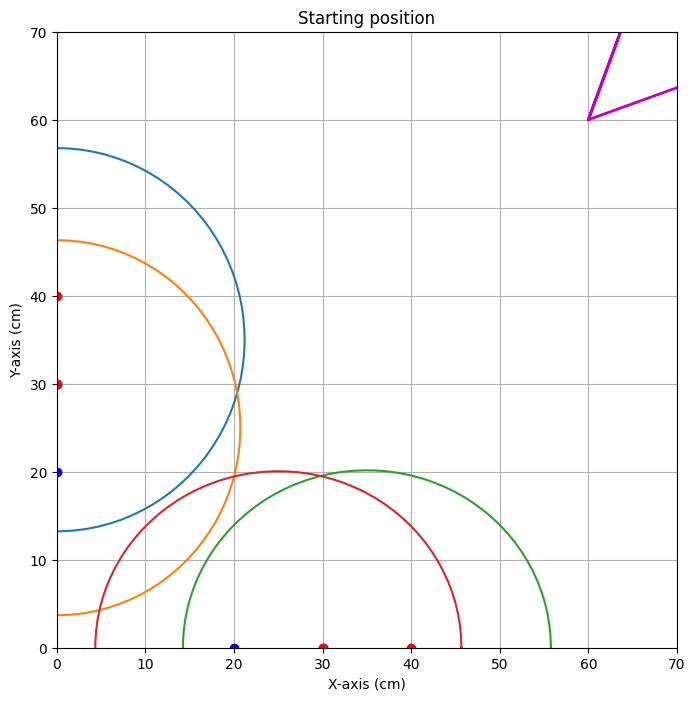


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.690


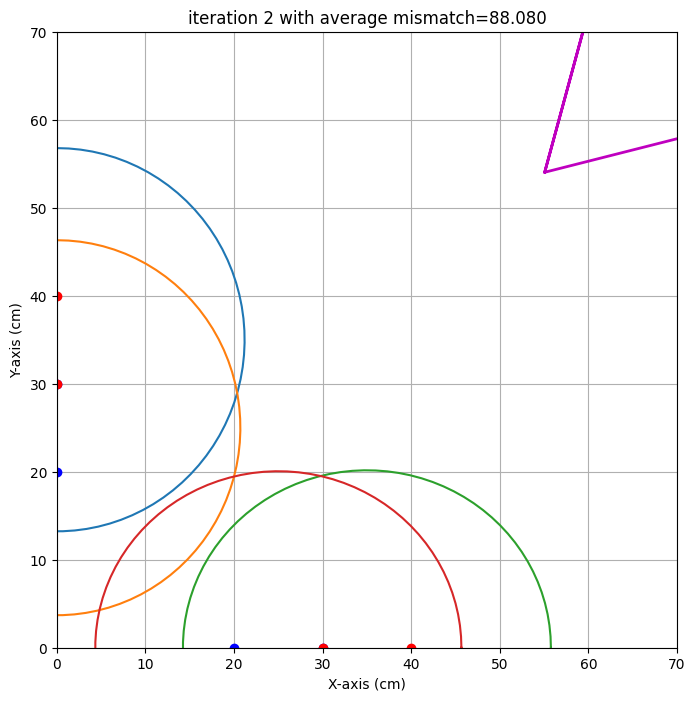

end iteration 2 with average mismatch=88.080


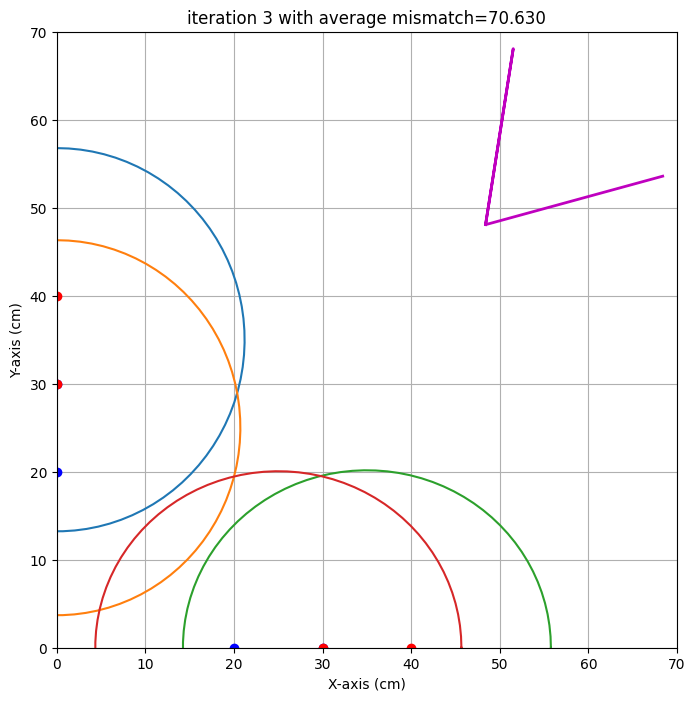

end iteration 3 with average mismatch=70.630


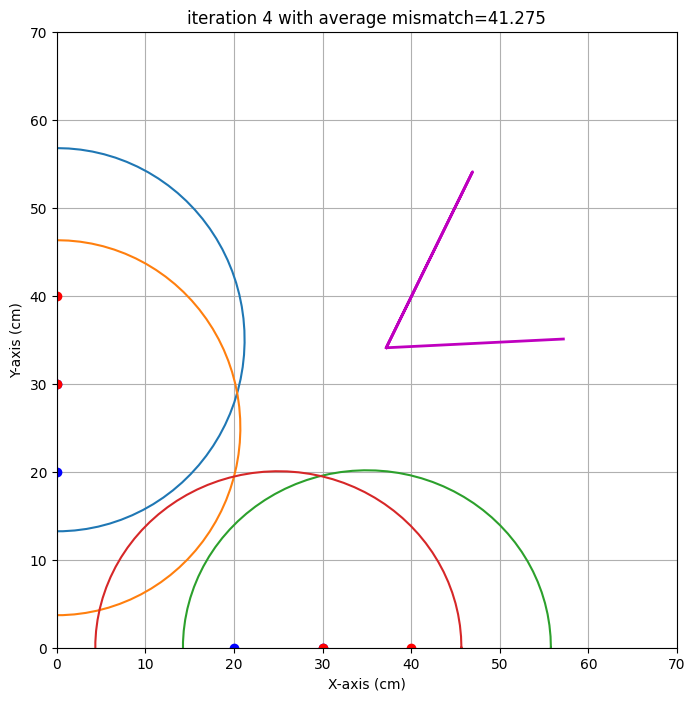

end iteration 4 with average mismatch=41.275


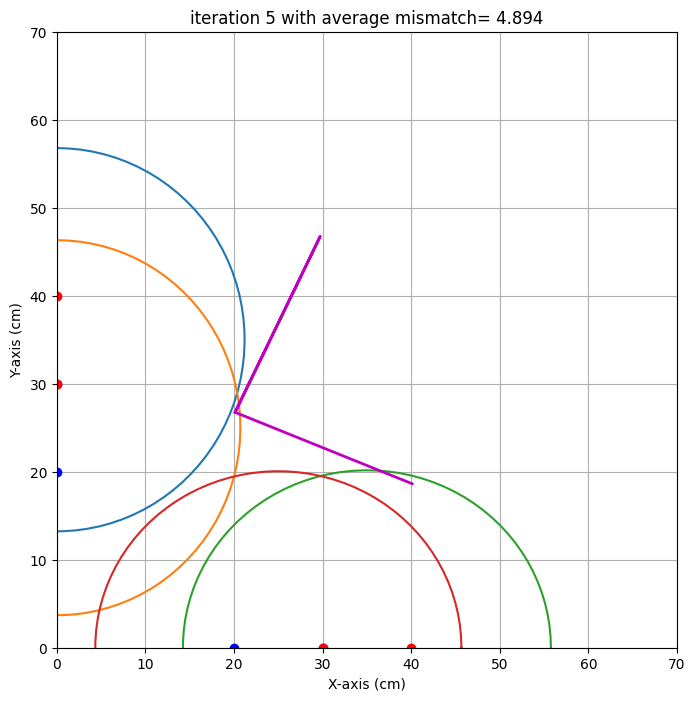

end iteration 5 with average mismatch= 4.894


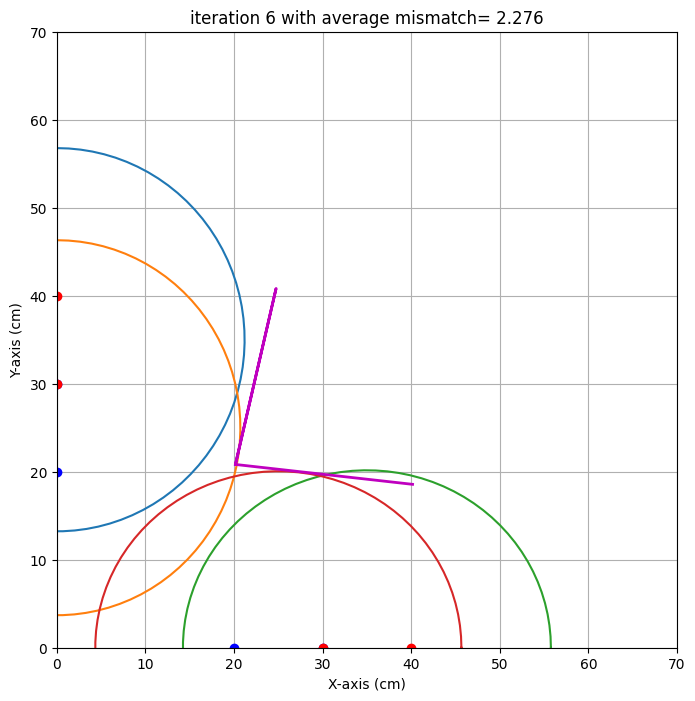

end iteration 6 with average mismatch= 2.276


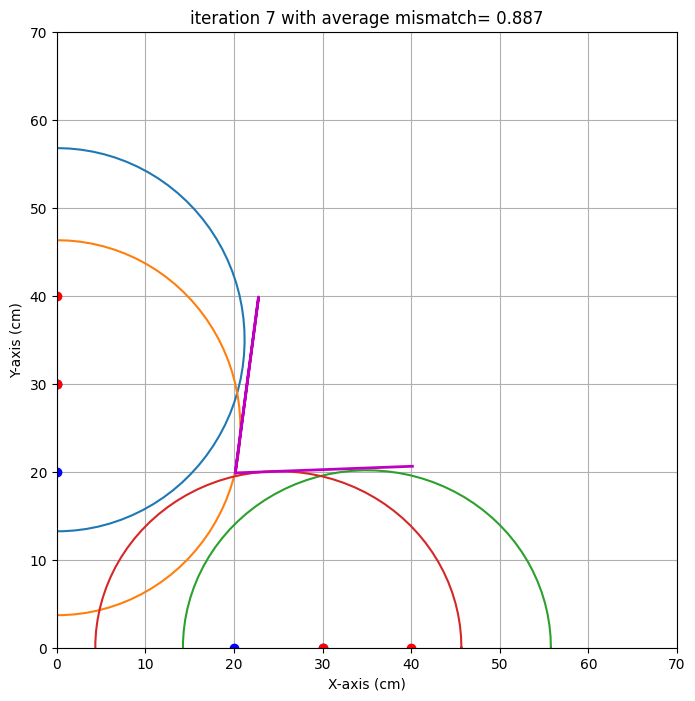

end iteration 7 with average mismatch= 0.887


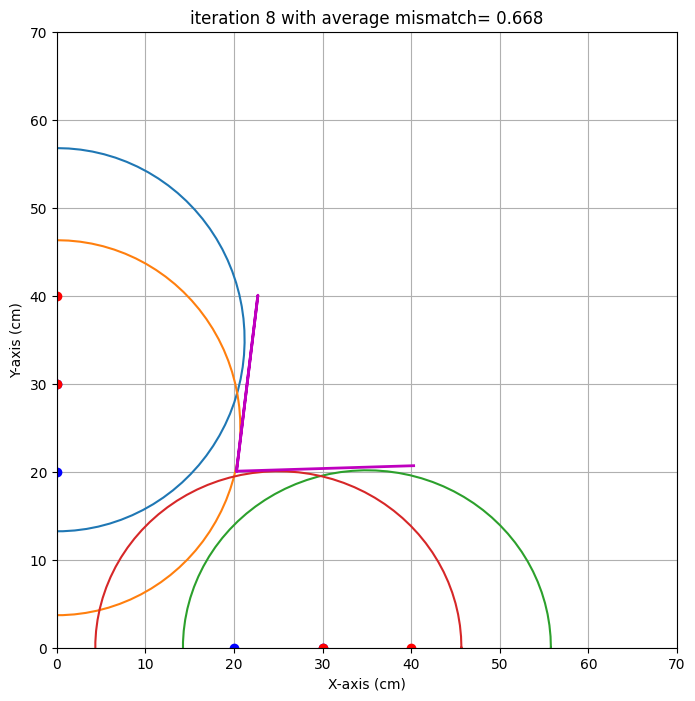

end iteration 8 with average mismatch= 0.668


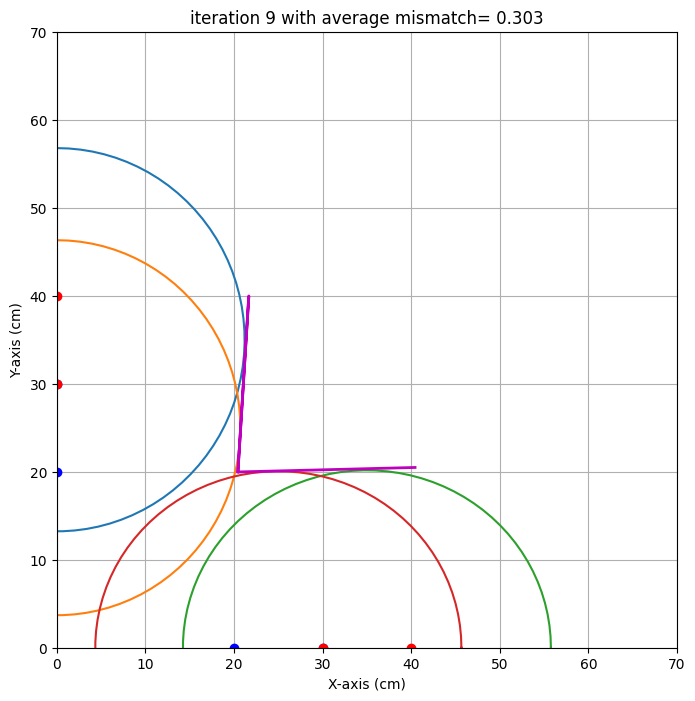

end iteration 9 with average mismatch= 0.303
end iteration 10 with average mismatch= 0.291
end iteration 11 with average mismatch= 0.284
end iteration 12 with average mismatch= 0.280
end iteration 13 with average mismatch= 0.280
end iteration 14 with average mismatch= 0.280
end iteration 15 with average mismatch= 0.280
end iteration 16 with average mismatch= 0.277
end iteration 17 with average mismatch= 0.271
end iteration 18 with average mismatch= 0.269


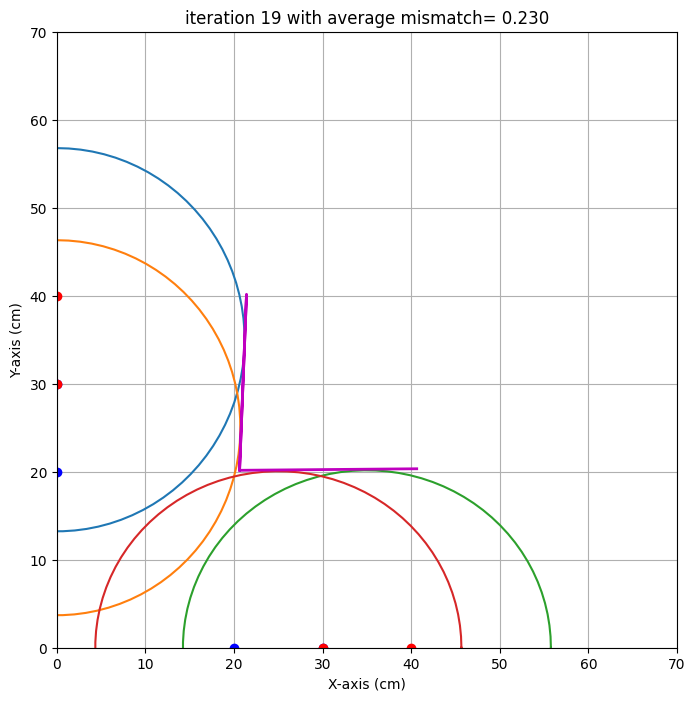

end iteration 19 with average mismatch= 0.230
end iteration 20 with average mismatch= 0.215
end iteration 21 with average mismatch= 0.211
end iteration 22 with average mismatch= 0.210
end iteration 23 with average mismatch= 0.210
end iteration 24 with average mismatch= 0.210
end iteration 25 with average mismatch= 0.210
end iteration 26 with average mismatch= 0.210
end iteration 27 with average mismatch= 0.210
end iteration 28 with average mismatch= 0.210
end iteration 29 with average mismatch= 0.210
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.210
###############################################################################
end of iteration  30
Best alpha=   0.50 with uncertainty=   2.32
Best beta =   2.24 with uncertainty=   0.81
Best x0   =  20.62 with uncertainty=   0.21
Best y0   =  20.14 with uncertainty=   0.41
############

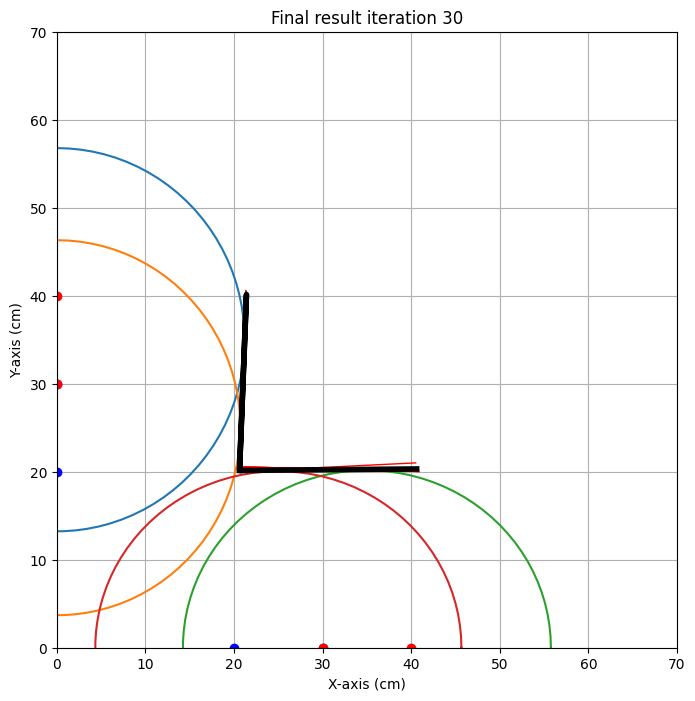

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.55],
    [0,30,0,20,42.62],
    #[0,10,0,20,3.0,170.63],
    [40,0,30,0,41.55],
    [30,0,20,0,41.34],
    #[10,0,20,0,153.37],
    #[10,0,0,10,127.64]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.6 cm met een standaardafwijking van 0.2 cm 
y0: 20.1 cm met een standaardafwijking van 0.4 cm 
alpha: 0.5 graden met een standaardafwijking van 2.3 graad 
beta: 2.2 graden met een standaardafwijking van 0.8 graad 



## Opdracht 5: Iteratie 0

#### algoritme Thomas Haak
Voeg een foto in van het algoritme van het eerste groepslid
![Alt](def4_alg_thomas.jpg "L11")

#### algoritme Matthias Grablowitz
Voeg een foto in van het algoritme van het tweede groepslid
![Alt](def4_alg_matthias.jpg "L11")

#### algoritme Chinming Zhu
Voeg een foto in van het algoritme van het derde groepslid
![Alt](def_alg_chinming.jpg "L11")

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!
# NVT

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  25,
           'y0': 41,
           'alpha' : 4,
           'beta' : -4,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thomas Haak' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,30,0,85.12],
    #[10,0,20,0,144],
    [30,0,40,0,82.9],
    #[0,20,0,30,190],
    [0,40,0,50,49.62],
    #[0,30,0,40,151],
    [0,50,0,50,47.76]
    ]),
       'Matthias Grablowitz' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,40,49.31],
    [0,60,0,50,46.4],
    [55,0,45,0,85.4],
    [50,0,40,0,84.12],
    [60,0,50,0,89.36],
    ]),
       'Chinming Zhu' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,17.5,0,22.5,180],
    [0,52.5,0,57.5,45.8],
    [0,61.25,0,66.25,46.3],
    #[17.5,0,22.5,0,169],
    [52.5,0,57.5,0,89.5],
    #[61.25,0,66.25,0,150],
    [43.75,0,48.75,0,84]
    ])
      }

## Opdracht 7: Evaluatie.

Thomas Haak
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  20   0  30   0  85.12
1  30   0  40   0  82.90
2   0  40   0  50  49.62
3   0  50   0  50  47.76


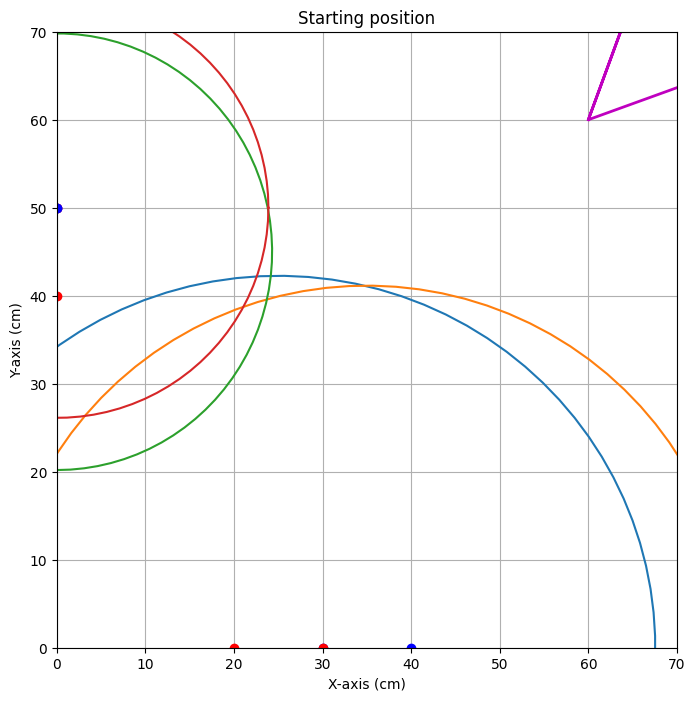


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.606


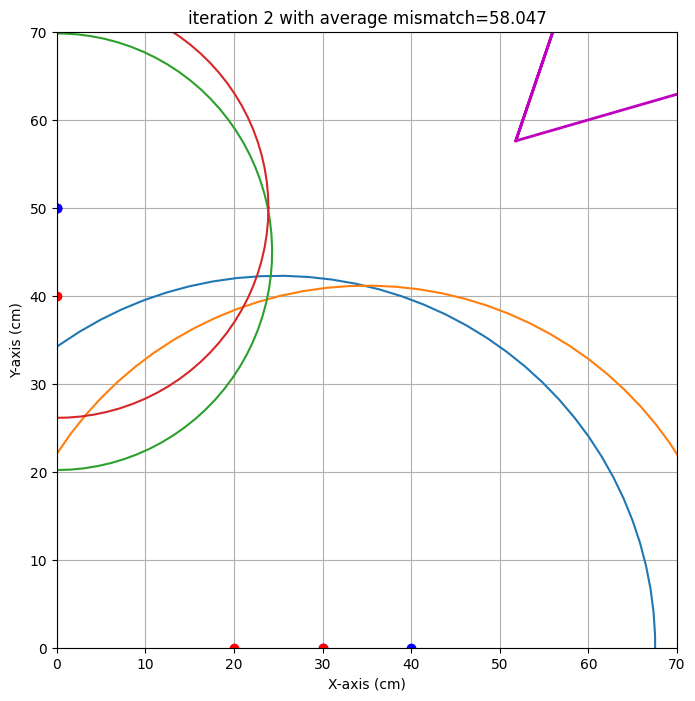

end iteration 2 with average mismatch=58.047


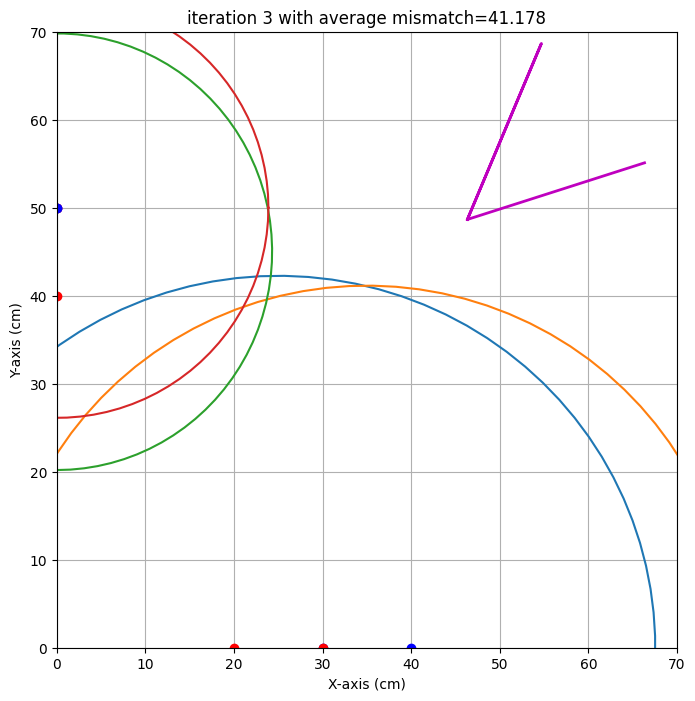

end iteration 3 with average mismatch=41.178


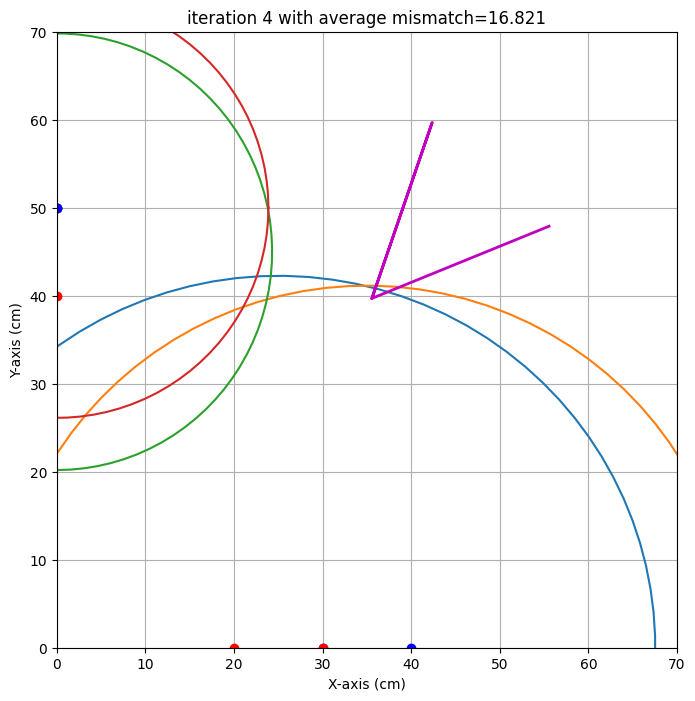

end iteration 4 with average mismatch=16.821


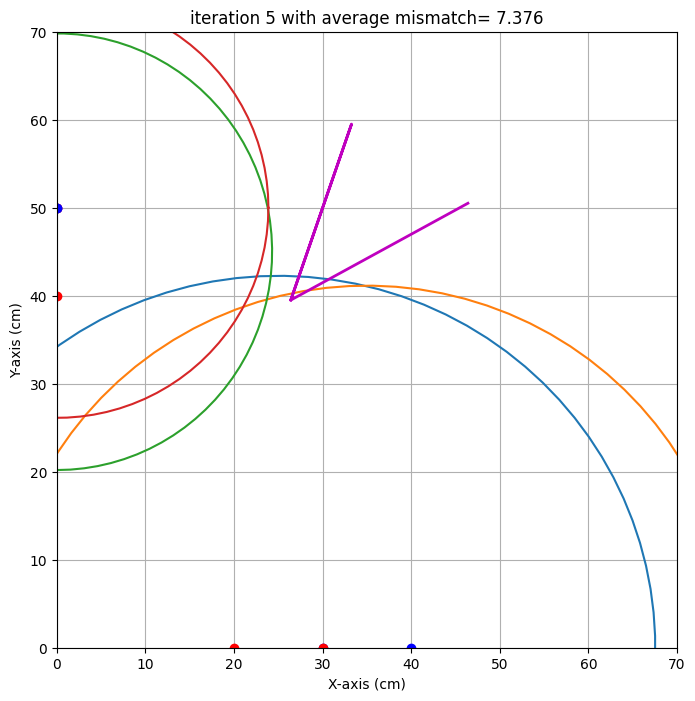

end iteration 5 with average mismatch= 7.376


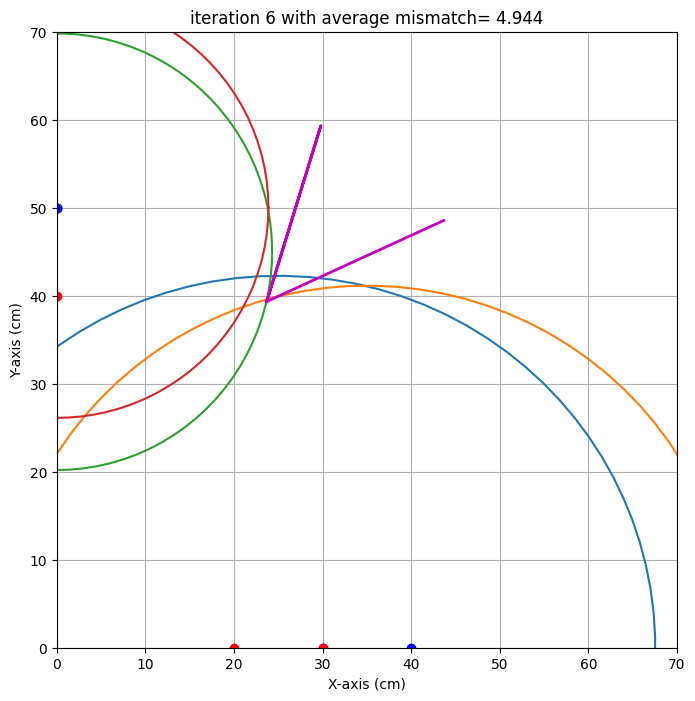

end iteration 6 with average mismatch= 4.944


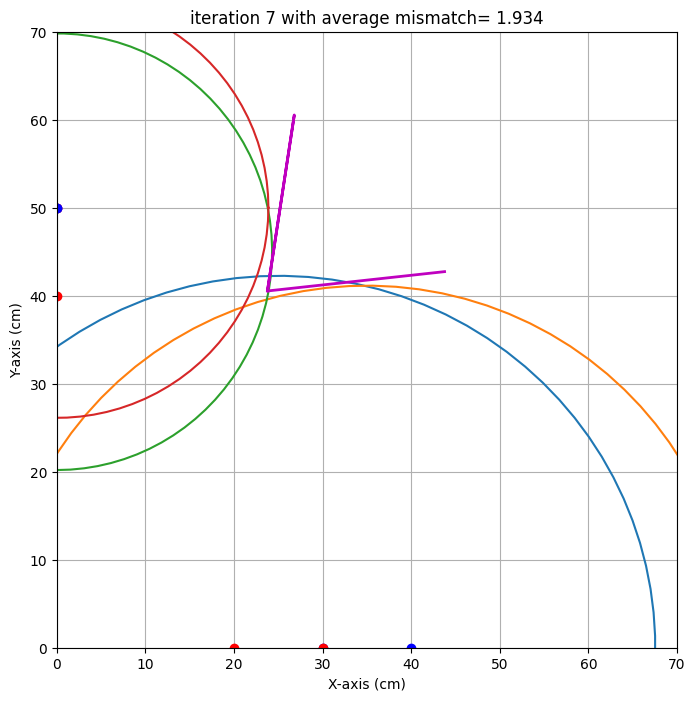

end iteration 7 with average mismatch= 1.934


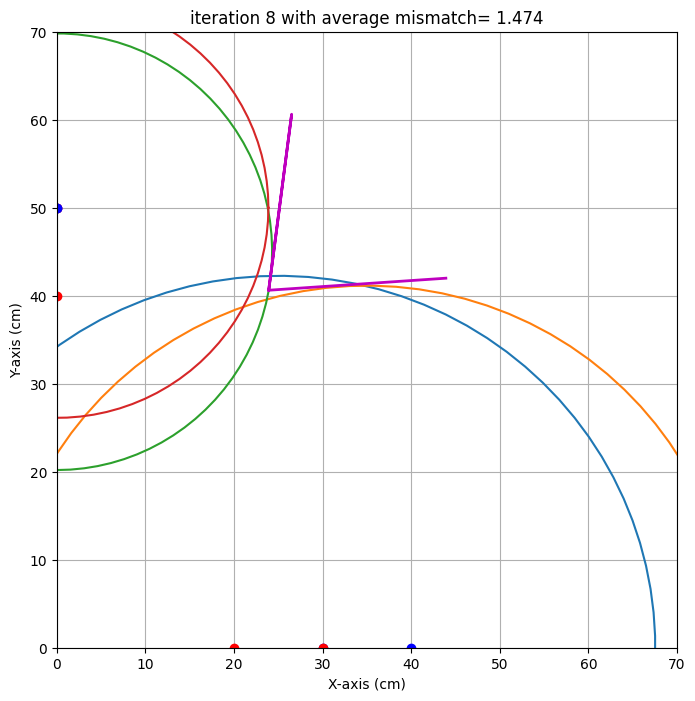

end iteration 8 with average mismatch= 1.474
end iteration 9 with average mismatch= 1.355


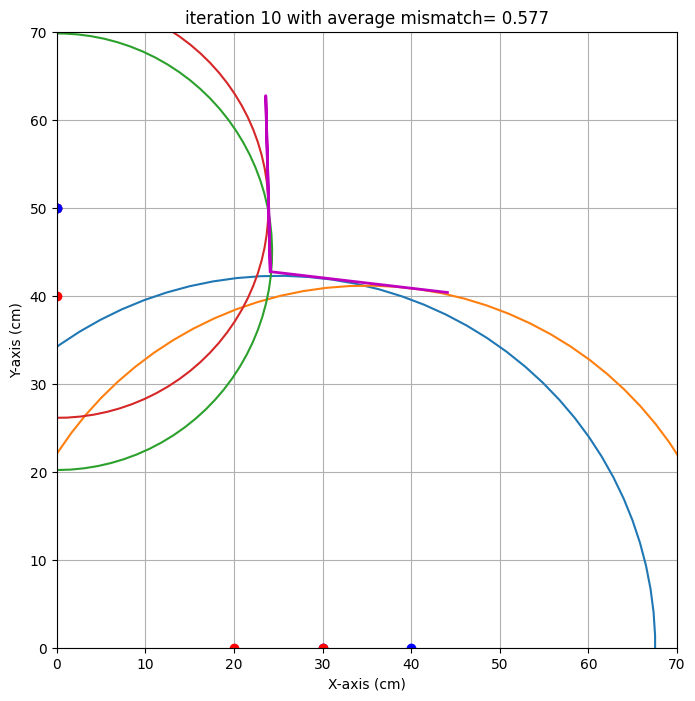

end iteration 10 with average mismatch= 0.577


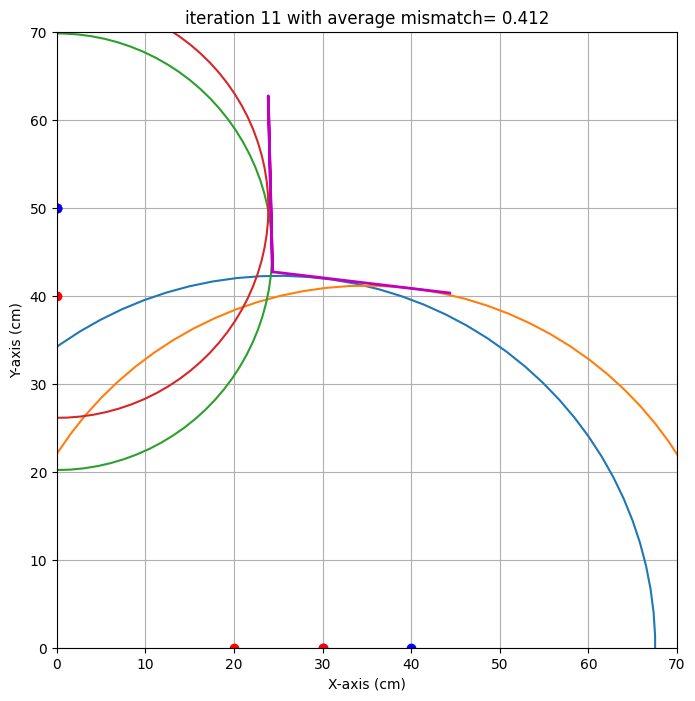

end iteration 11 with average mismatch= 0.412
end iteration 12 with average mismatch= 0.383
end iteration 13 with average mismatch= 0.360
end iteration 14 with average mismatch= 0.356
end iteration 15 with average mismatch= 0.354
end iteration 16 with average mismatch= 0.353
end iteration 17 with average mismatch= 0.353
end iteration 18 with average mismatch= 0.353
end iteration 19 with average mismatch= 0.353
end iteration 20 with average mismatch= 0.353


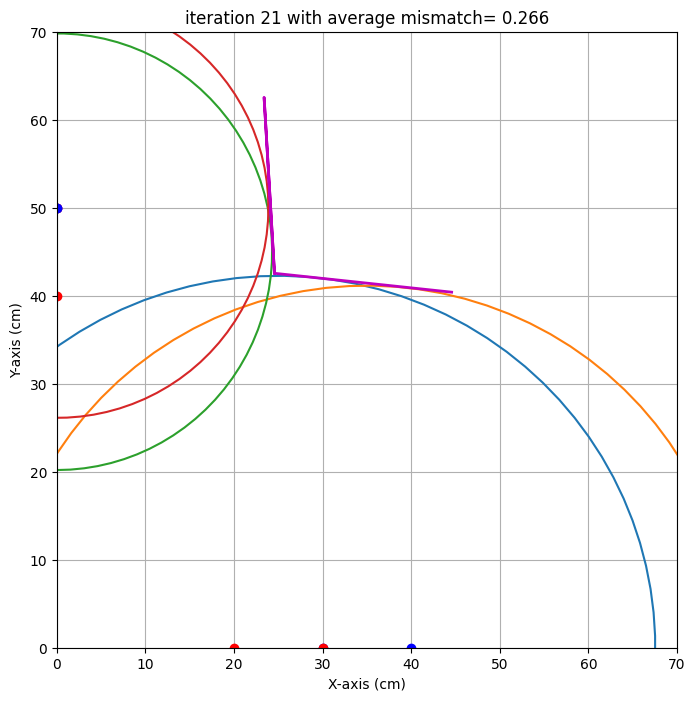

end iteration 21 with average mismatch= 0.266
end iteration 22 with average mismatch= 0.263


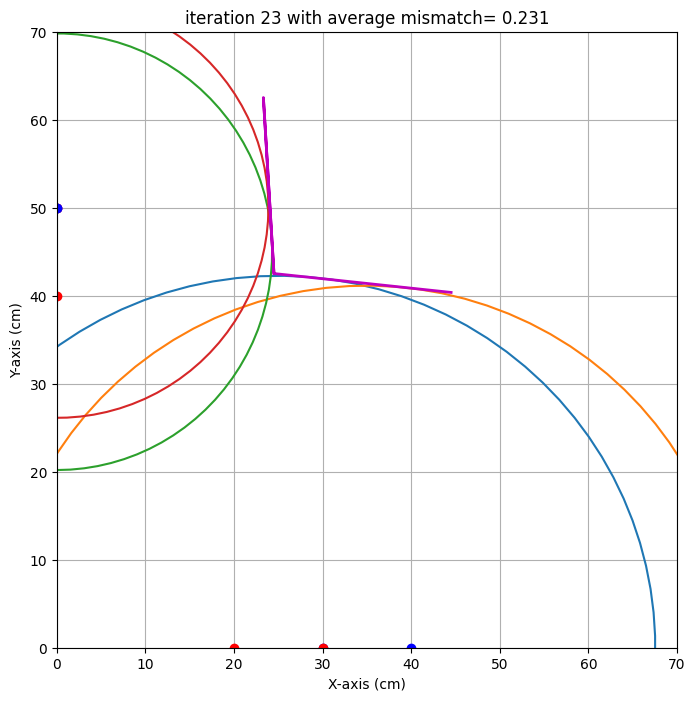

end iteration 23 with average mismatch= 0.231
end iteration 24 with average mismatch= 0.217
end iteration 25 with average mismatch= 0.217
end iteration 26 with average mismatch= 0.217
end iteration 27 with average mismatch= 0.217
end iteration 28 with average mismatch= 0.217
end iteration 29 with average mismatch= 0.217
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.217
###############################################################################
end of iteration  30
Best alpha=  -6.13 with uncertainty=   3.45
Best beta =  -3.43 with uncertainty=   5.40
Best x0   =  24.49 with uncertainty=   0.70
Best y0   =  42.53 with uncertainty=   1.03
###############################################################################


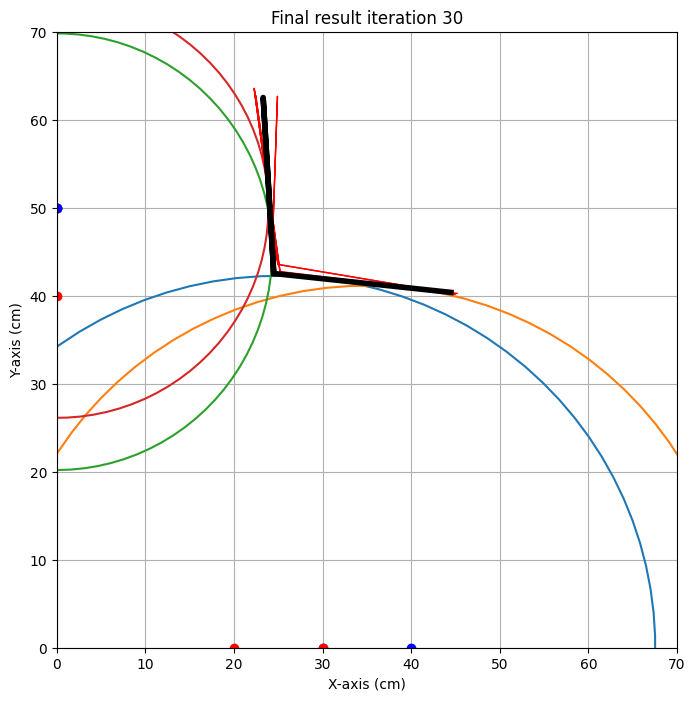

{'alpha': np.float64(-6.125586282555708), 'alpha_eps': np.float64(3.4549721481161013), 'beta': np.float64(-3.4339440744710363), 'beta_eps': np.float64(5.397703401951745), 'x0': np.float64(24.485254518438143), 'x0_eps': np.float64(0.7027955568804494), 'y0': np.float64(42.52525975331337), 'y0_eps': np.float64(1.0305660309686857)}
Matthias Grablowitz
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  40  49.31
1   0  60   0  50  46.40
2  55   0  45   0  85.40
3  50   0  40   0  84.12
4  60   0  50   0  89.36


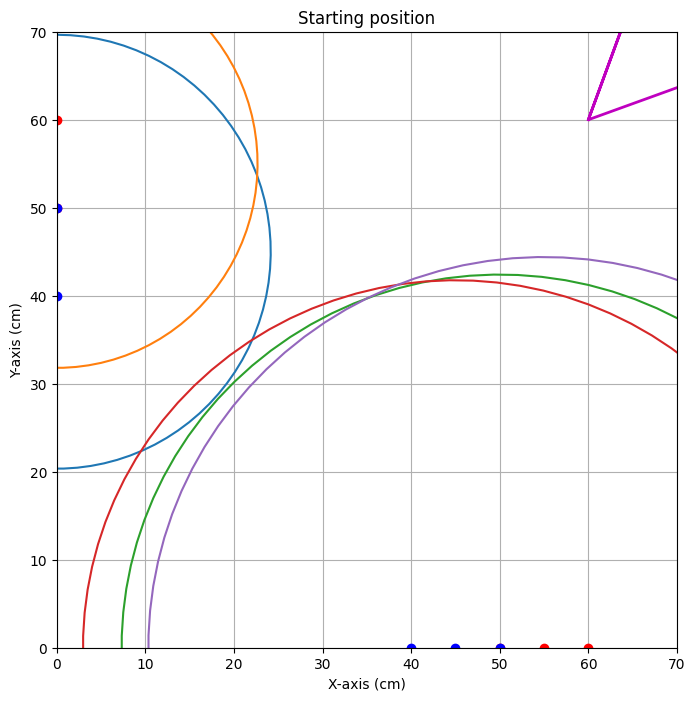


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.156


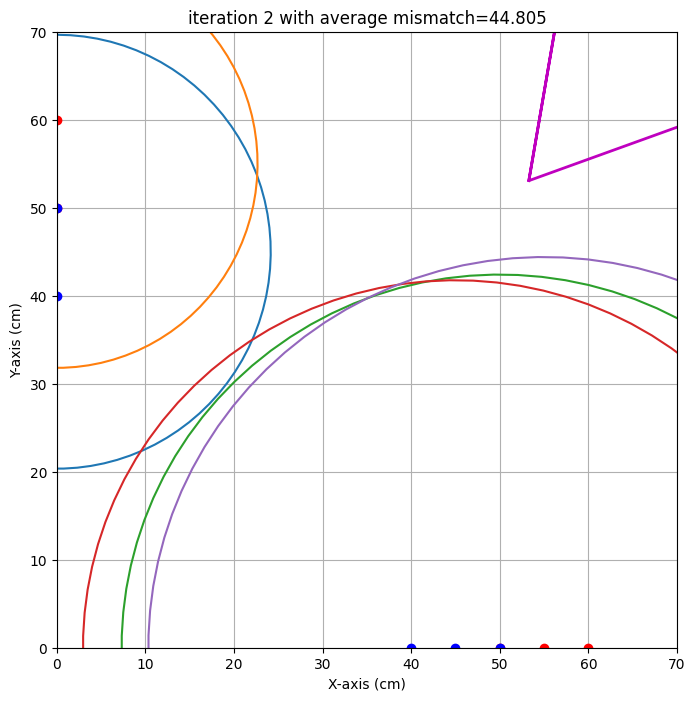

end iteration 2 with average mismatch=44.805


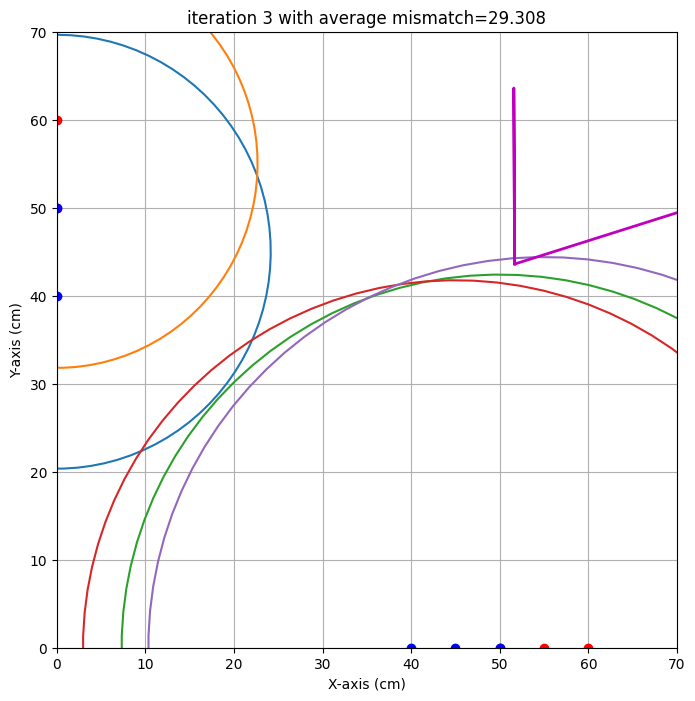

end iteration 3 with average mismatch=29.308


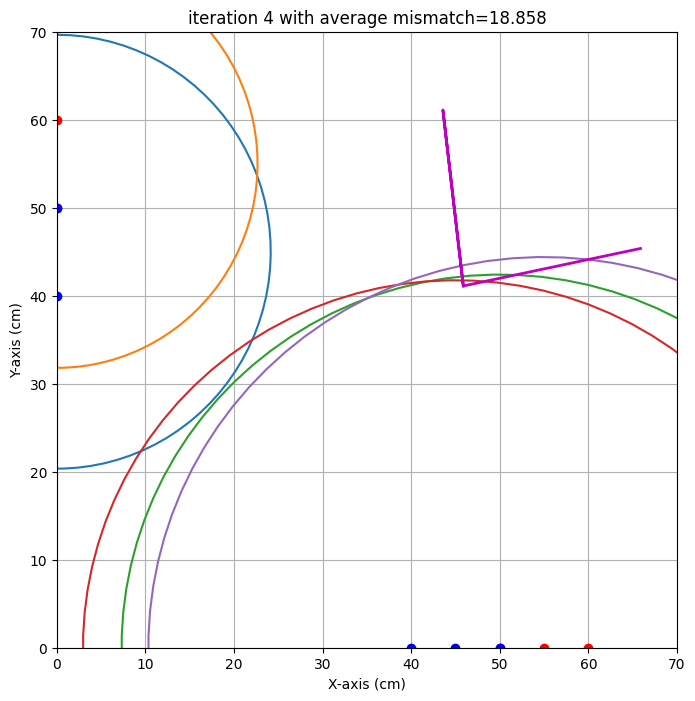

end iteration 4 with average mismatch=18.858


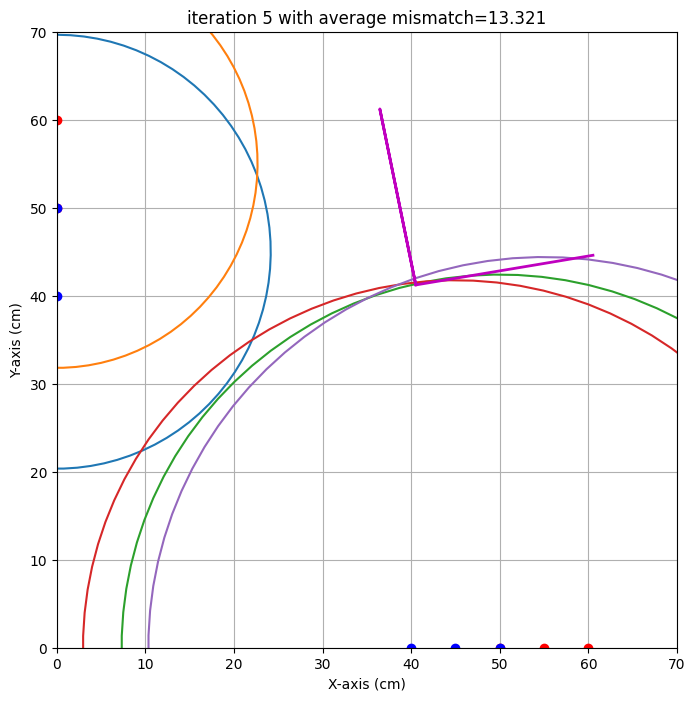

end iteration 5 with average mismatch=13.321


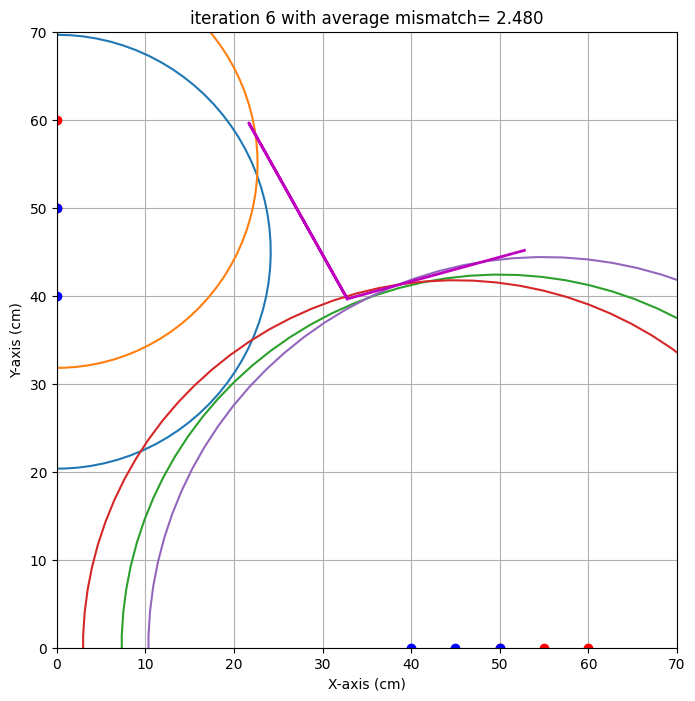

end iteration 6 with average mismatch= 2.480


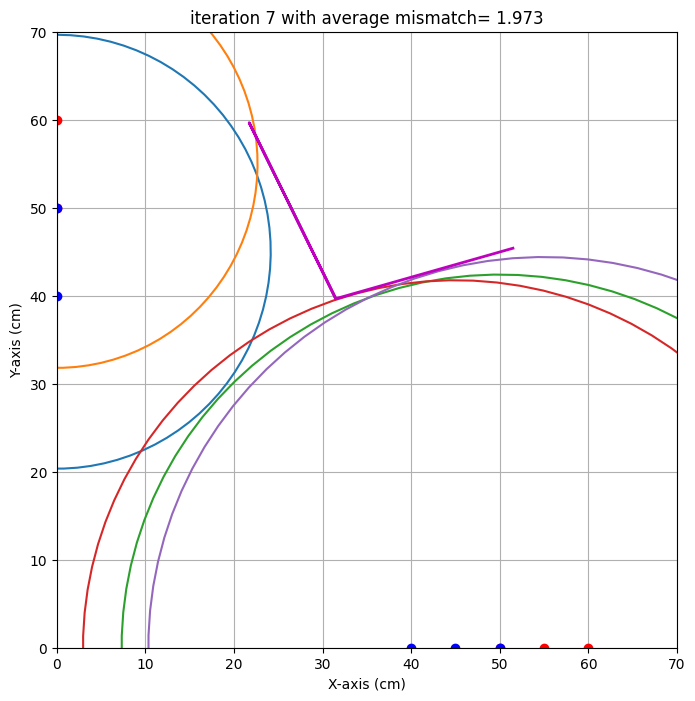

end iteration 7 with average mismatch= 1.973
end iteration 8 with average mismatch= 1.909
end iteration 9 with average mismatch= 1.897


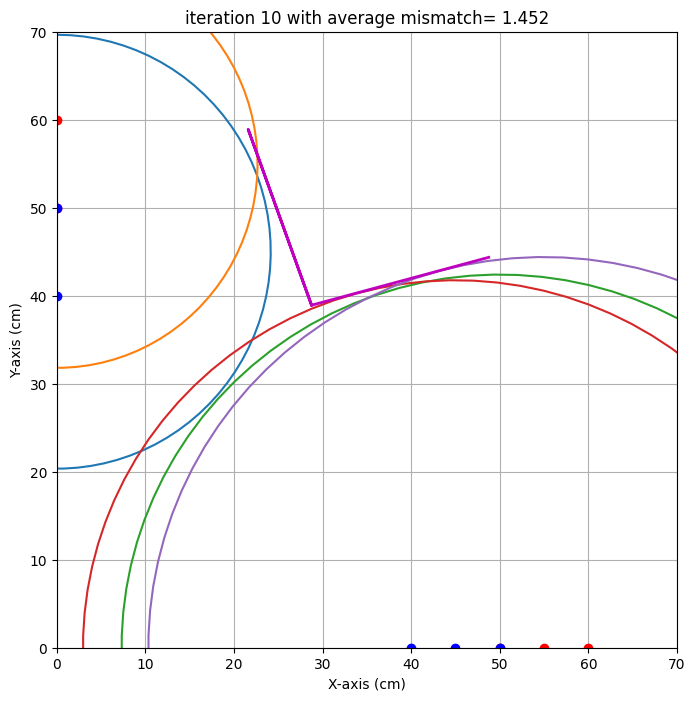

end iteration 10 with average mismatch= 1.452
end iteration 11 with average mismatch= 1.403
end iteration 12 with average mismatch= 1.352


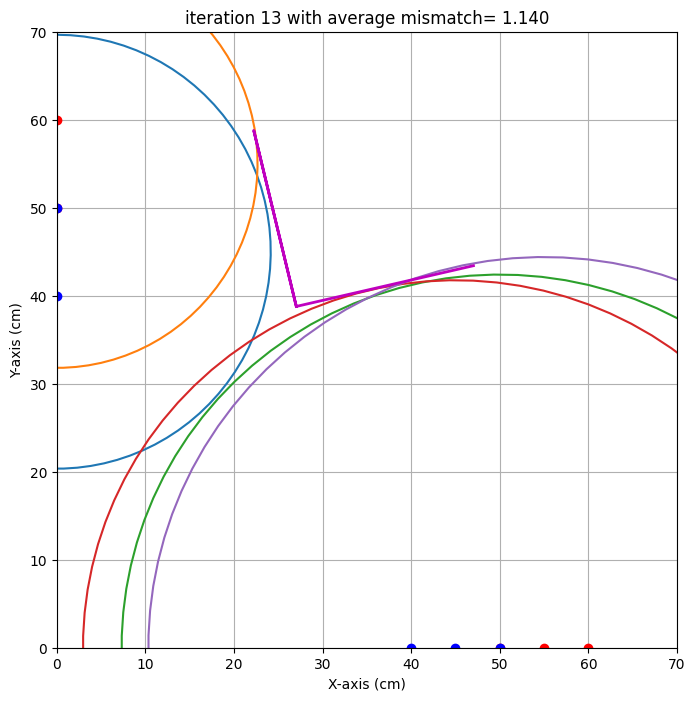

end iteration 13 with average mismatch= 1.140


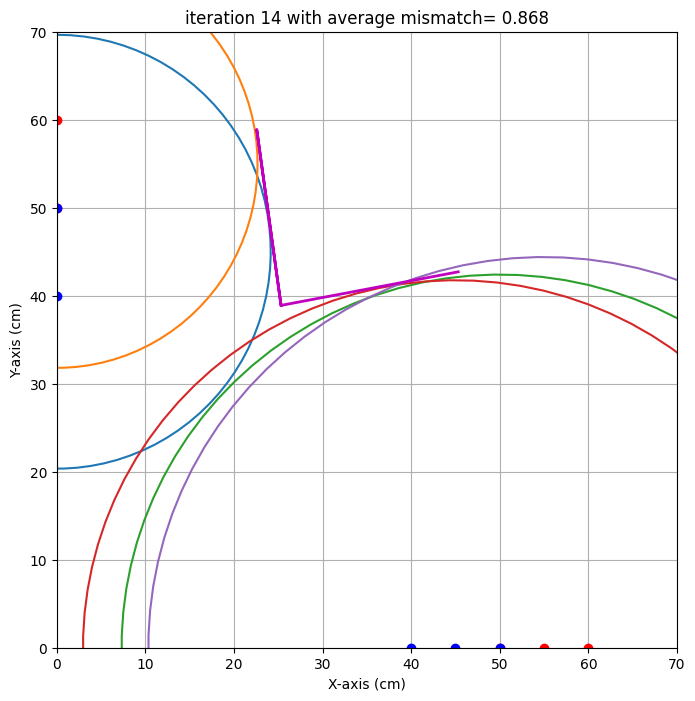

end iteration 14 with average mismatch= 0.868


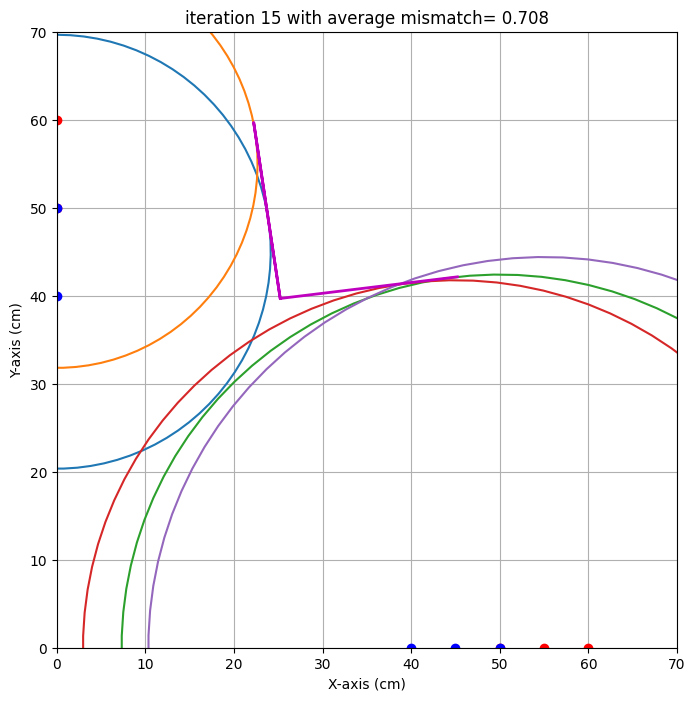

end iteration 15 with average mismatch= 0.708
end iteration 16 with average mismatch= 0.708
end iteration 17 with average mismatch= 0.708
end iteration 18 with average mismatch= 0.708
end iteration 19 with average mismatch= 0.708
end iteration 20 with average mismatch= 0.708
end iteration 21 with average mismatch= 0.708
end iteration 22 with average mismatch= 0.708
end iteration 23 with average mismatch= 0.708
end iteration 24 with average mismatch= 0.708
end iteration 25 with average mismatch= 0.708
end iteration 26 with average mismatch= 0.708
end iteration 27 with average mismatch= 0.708
end iteration 28 with average mismatch= 0.708
end iteration 29 with average mismatch= 0.708
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.708
###############################################################################
end of iteration  30
Best alpha=   7.00 with uncertainty=   8.31
Best beta 

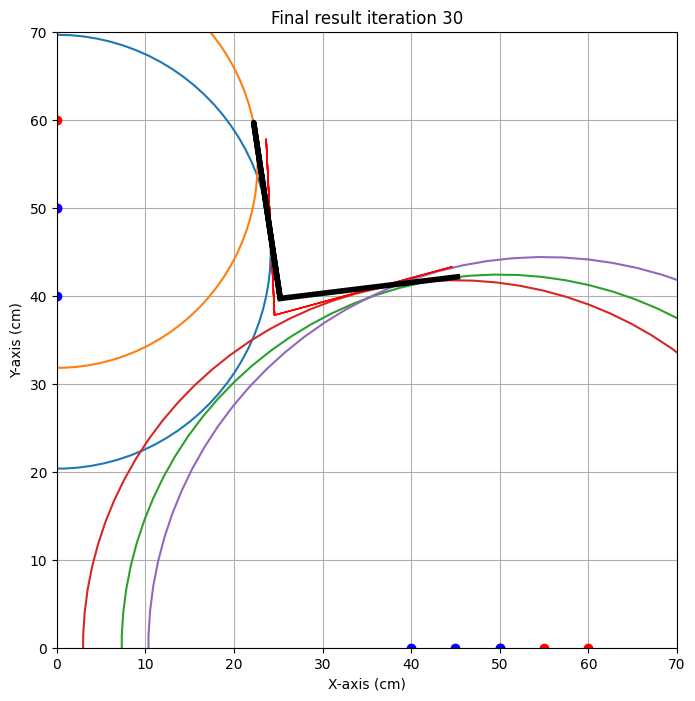

{'alpha': np.float64(6.997757505567344), 'alpha_eps': np.float64(8.307751237163787), 'beta': np.float64(-8.51910453258454), 'beta_eps': np.float64(5.8056359192739775), 'x0': np.float64(25.21259727588394), 'x0_eps': np.float64(0.6387966614981799), 'y0': np.float64(39.68910146349176), 'y0_eps': np.float64(1.892212953934056)}
Chinming Zhu
Running the imaging algorithm with the following data:
      xs     ys     xr     yr     R
0   0.00  52.50   0.00  57.50  45.8
1   0.00  61.25   0.00  66.25  46.3
2  52.50   0.00  57.50   0.00  89.5
3  43.75   0.00  48.75   0.00  84.0


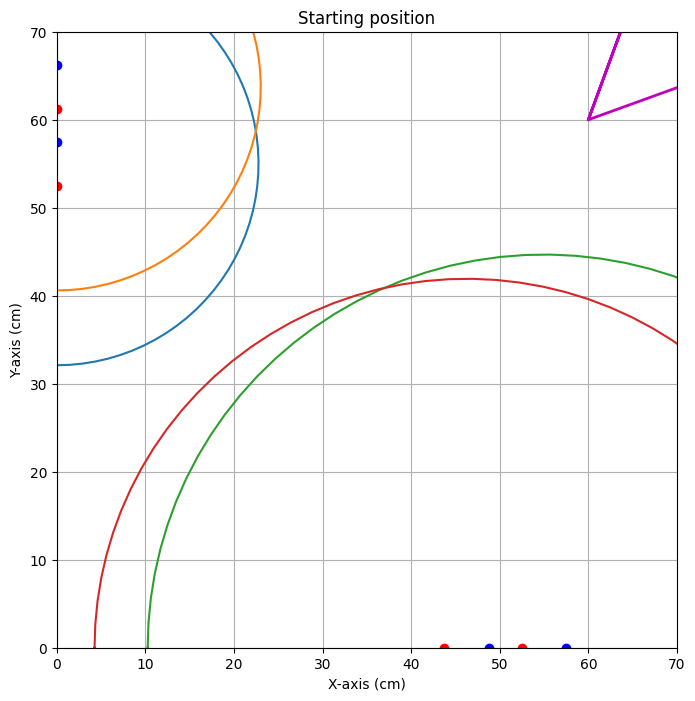


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.191


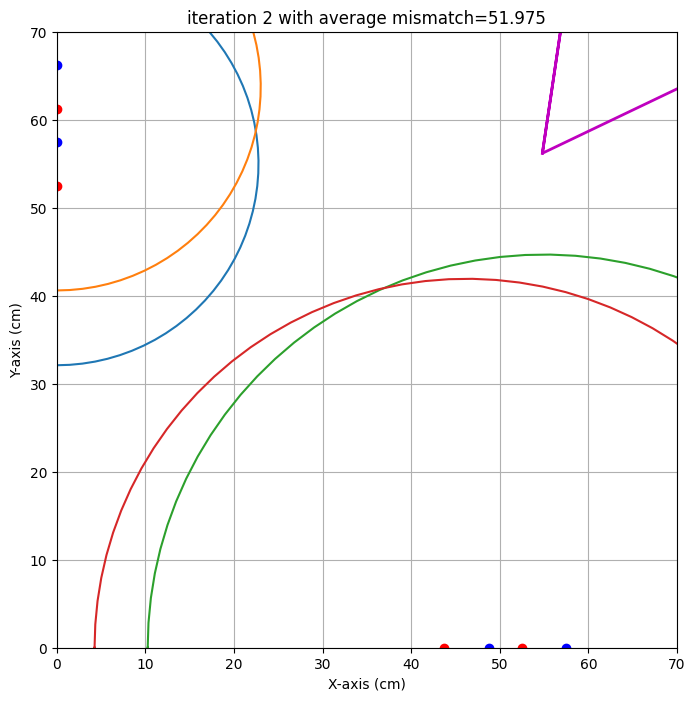

end iteration 2 with average mismatch=51.975


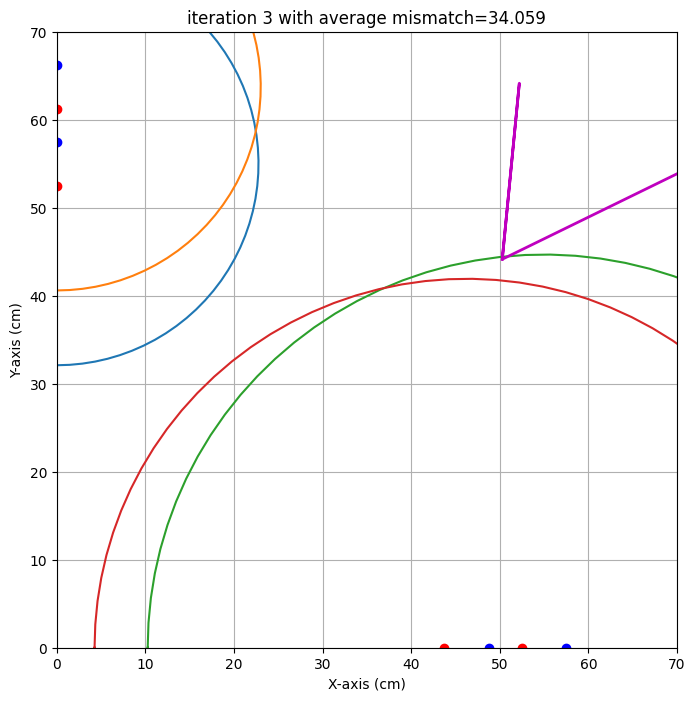

end iteration 3 with average mismatch=34.059


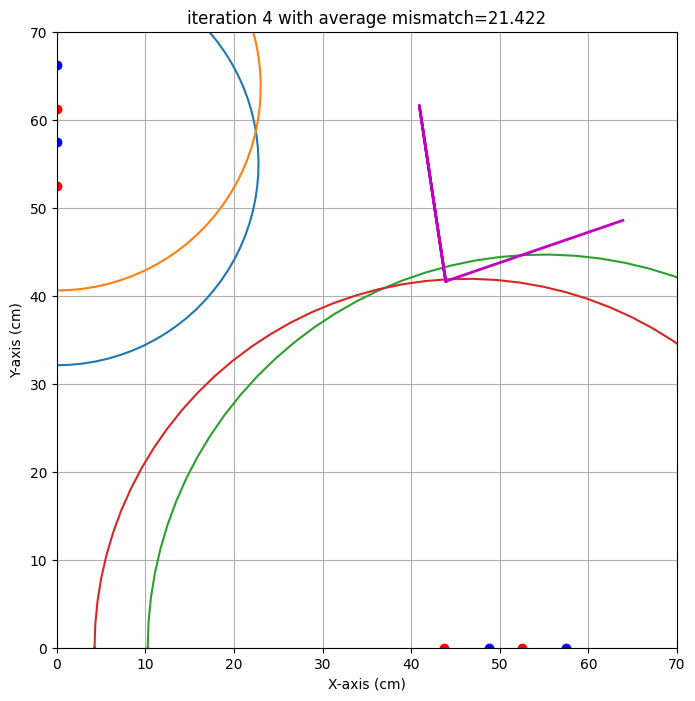

end iteration 4 with average mismatch=21.422


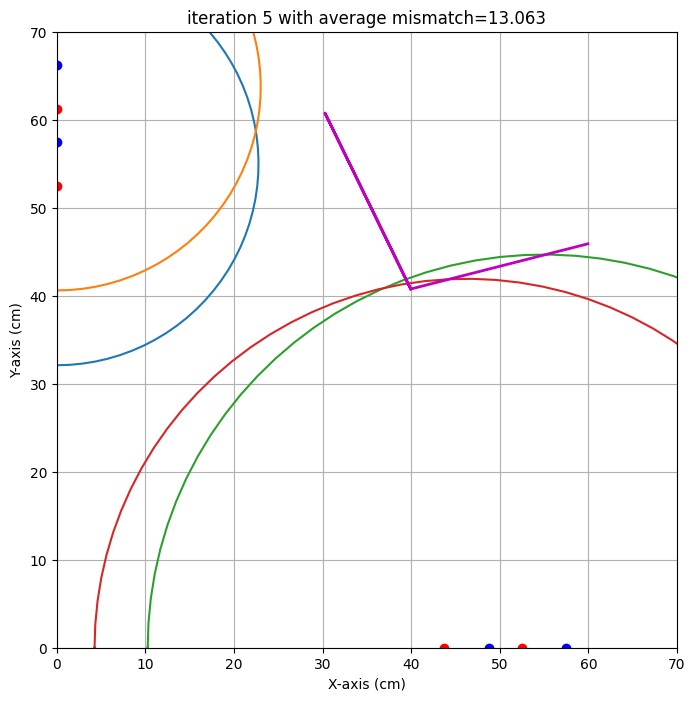

end iteration 5 with average mismatch=13.063


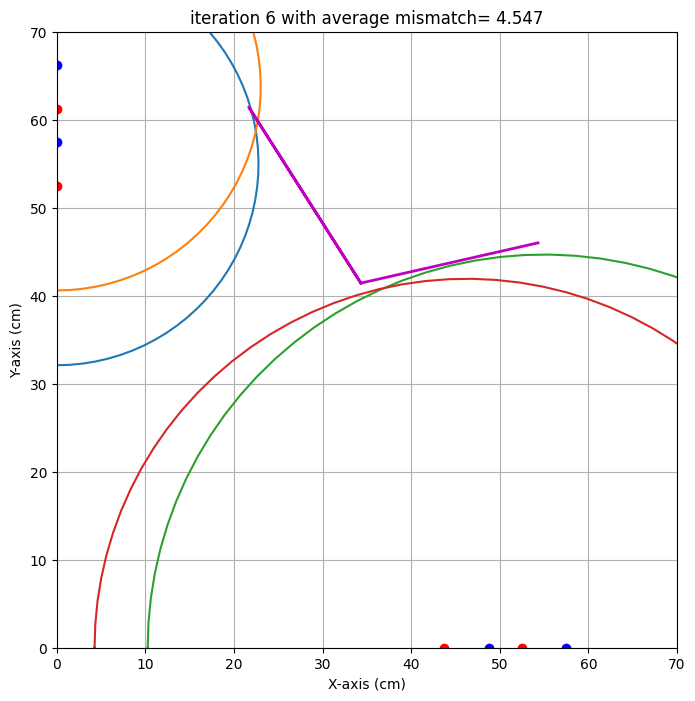

end iteration 6 with average mismatch= 4.547


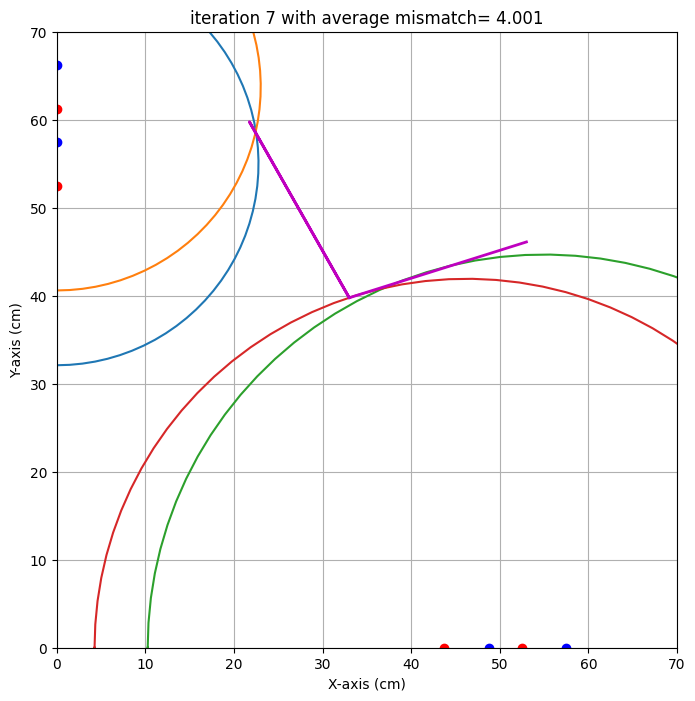

end iteration 7 with average mismatch= 4.001


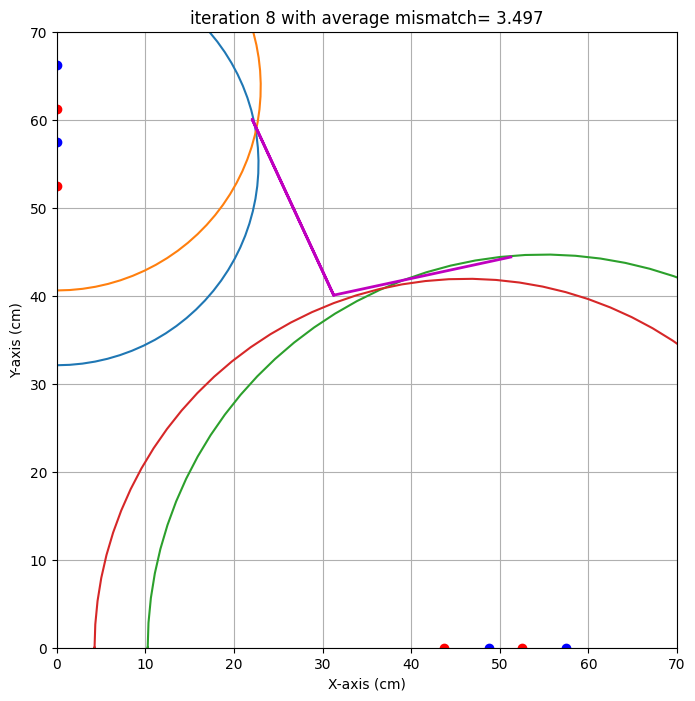

end iteration 8 with average mismatch= 3.497
end iteration 9 with average mismatch= 3.210


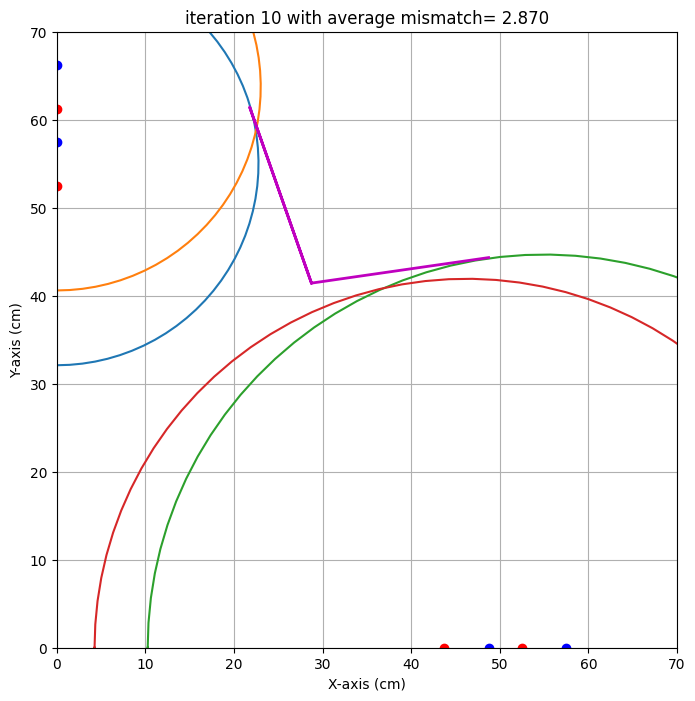

end iteration 10 with average mismatch= 2.870
end iteration 11 with average mismatch= 2.763
end iteration 12 with average mismatch= 2.514


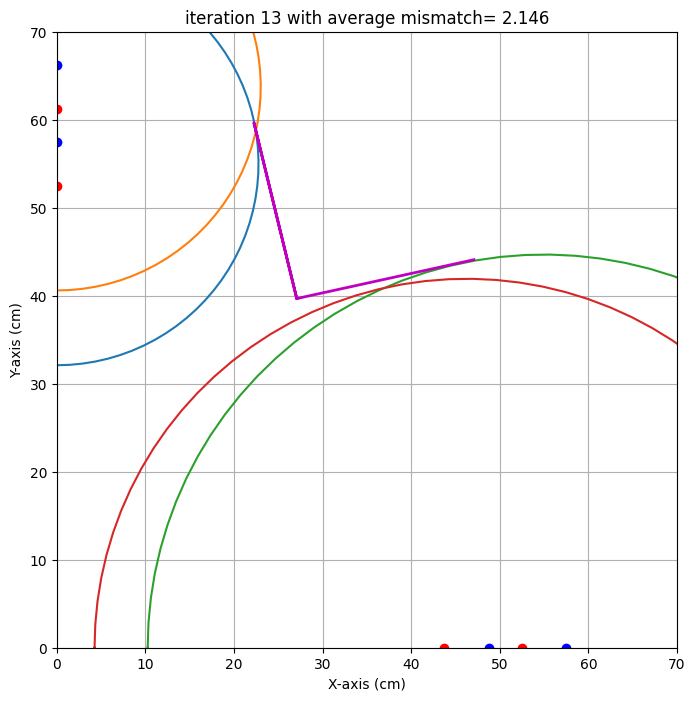

end iteration 13 with average mismatch= 2.146
end iteration 14 with average mismatch= 2.146
end iteration 15 with average mismatch= 2.146
end iteration 16 with average mismatch= 2.139
end iteration 17 with average mismatch= 2.139


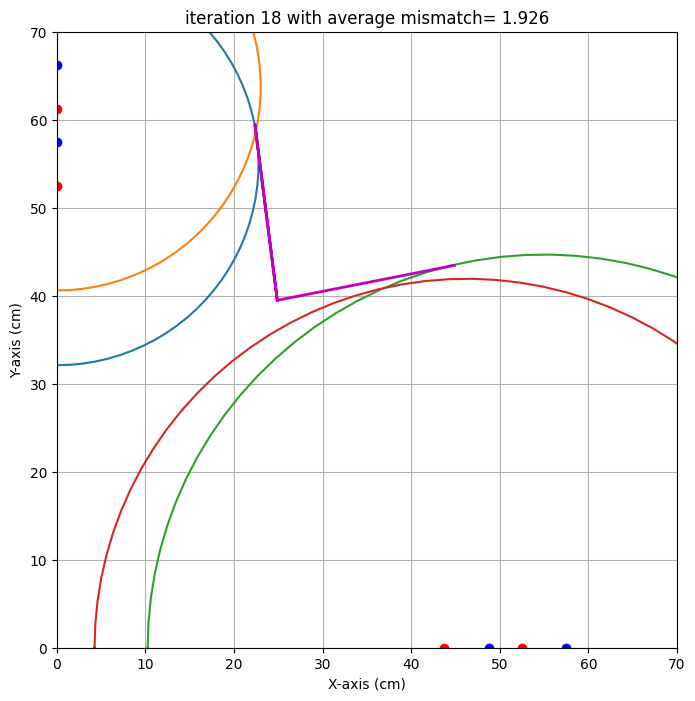

end iteration 18 with average mismatch= 1.926
end iteration 19 with average mismatch= 1.827
end iteration 20 with average mismatch= 1.771
end iteration 21 with average mismatch= 1.744
end iteration 22 with average mismatch= 1.731
end iteration 23 with average mismatch= 1.709
end iteration 24 with average mismatch= 1.698
end iteration 25 with average mismatch= 1.693
end iteration 26 with average mismatch= 1.693
end iteration 27 with average mismatch= 1.693
end iteration 28 with average mismatch= 1.693
end iteration 29 with average mismatch= 1.693
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.693
###############################################################################
end of iteration  30
Best alpha=   5.64 with uncertainty=   3.80
Best beta =  -1.05 with uncertainty=   7.10
Best x0   =  23.03 with uncertainty=   1.90
Best y0   =  40.68 with uncertainty=   1.24
################

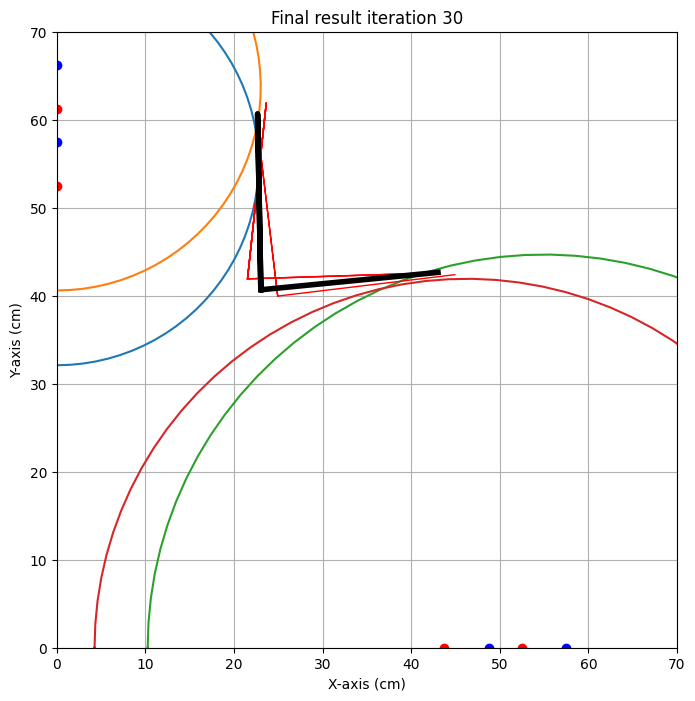

{'alpha': np.float64(5.636383765014348), 'alpha_eps': np.float64(3.7980895815439712), 'beta': np.float64(-1.046944043345719), 'beta_eps': np.float64(7.096955150897089), 'x0': np.float64(23.025006486405083), 'x0_eps': np.float64(1.9024647154627559), 'y0': np.float64(40.6760191692536), 'y0_eps': np.float64(1.2378879581427995)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Thomas Haak 
x0 target is : 25.0. Gevonden waarde: 24.5 cm met een standaardafwijking van 0.7 cm 
y0 target is : 41.0. Gevonden waarde: 42.5 cm met een standaardafwijking van 1.0 cm 
alpha target is : 4.0. Gevonden waarde: -6.1 graden met een standaardafwijking van 3.5 graad 
beta target is : -4.0. Gevonden waarde: -3.4 graden met een standaardafwijking van 5.4 graad 

Matthias Grablowitz 
x0 target is : 25.0. Gevonden waarde: 25.2 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.0. Gevonden waarde: 39.7 cm met een standaardafwijking van 1.9 cm 
alpha target is : 4.0. Gevonden waarde: 7.0 graden met een standaardafwijking van 8.3 graad 
beta target is : -4.0. Gevonden waarde: -8.5 graden met een standaardafwijking van 5.8 graad 

Chinming Zhu 
x0 target is : 25.0. Gevonden waarde: 23.0 cm met een standaardafwijking van 1.9 cm 
y0 target is : 41.0. Gevonden waarde: 40.7 cm met een standaardafwijking van 1.2 cm 
alpha target is : 4.0. Gevonden waarde: 5.6 graden met een standa

## Opdracht 8: Iteratie1+. 15:04.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

![Alt](def4_alg_it1.jpg "L11")


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  50   0  65.50
1  30   0  40   0  58.60
2  50   0  60   0  54.10
3   0  30   0  40  71.32
4   0  35   0  45  69.90
5   0  40   0  50  69.00


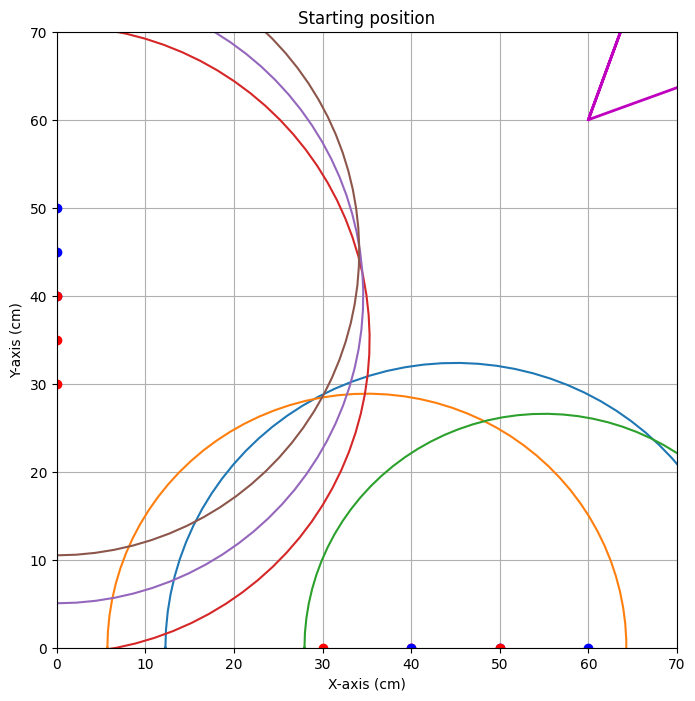


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.105


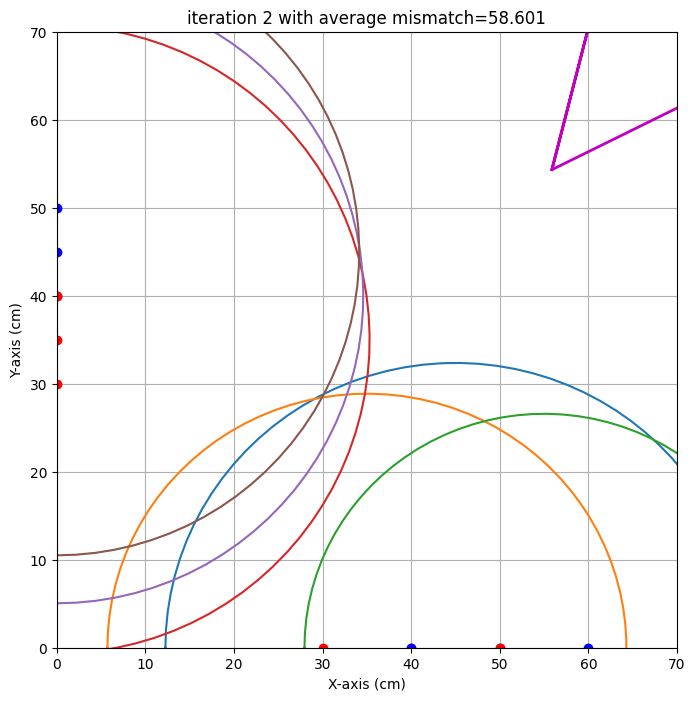

end iteration 2 with average mismatch=58.601


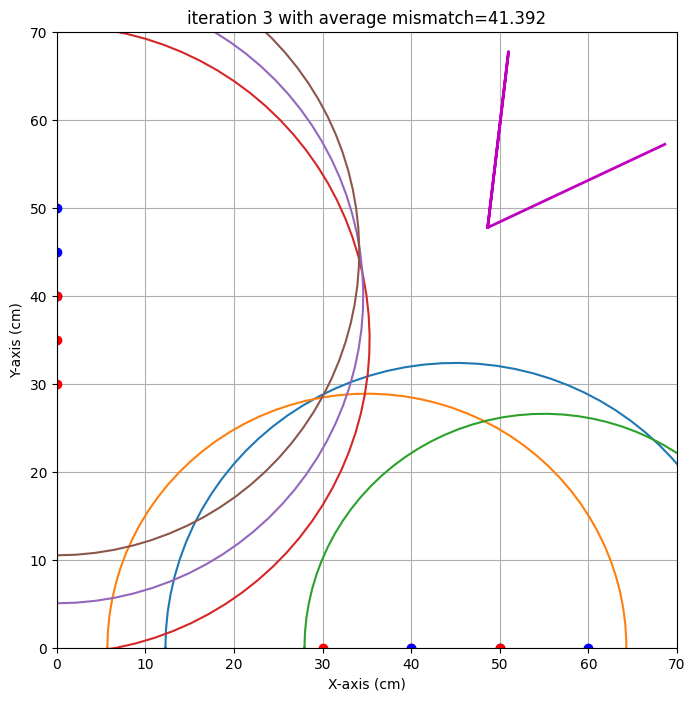

end iteration 3 with average mismatch=41.392


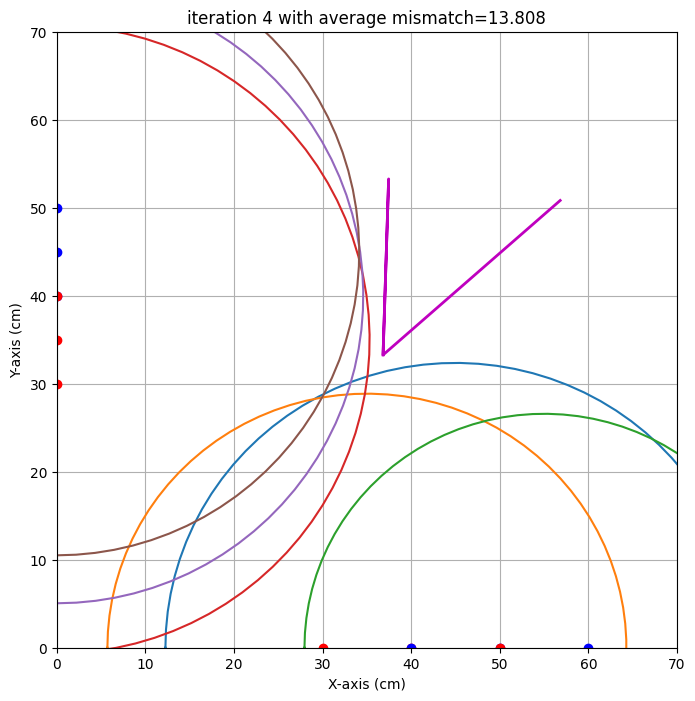

end iteration 4 with average mismatch=13.808


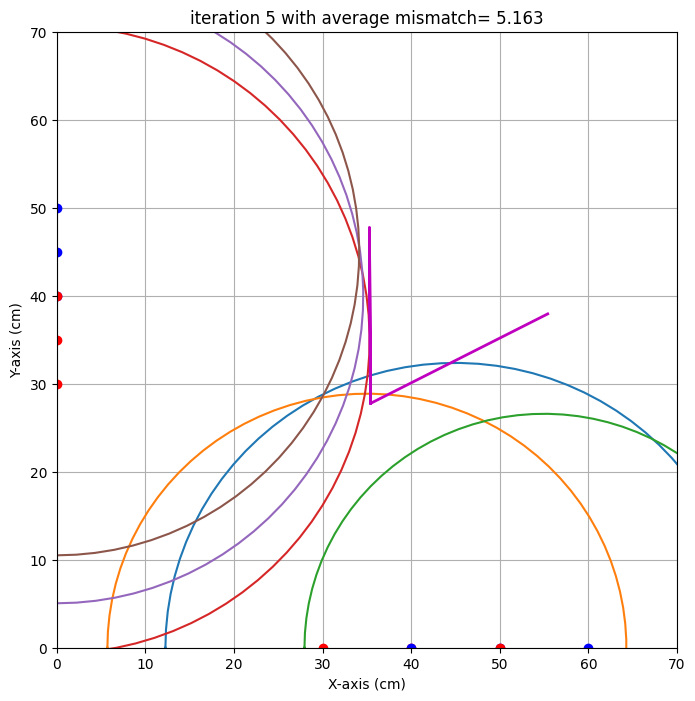

end iteration 5 with average mismatch= 5.163


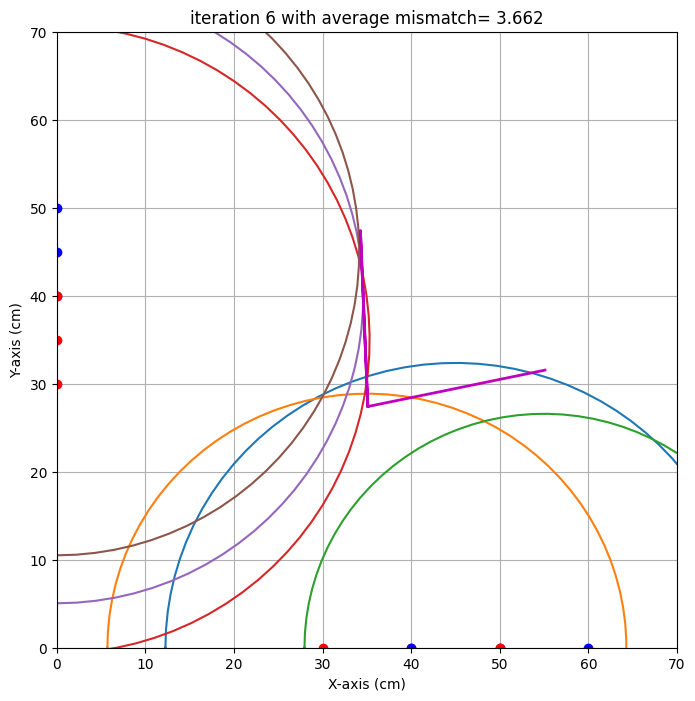

end iteration 6 with average mismatch= 3.662


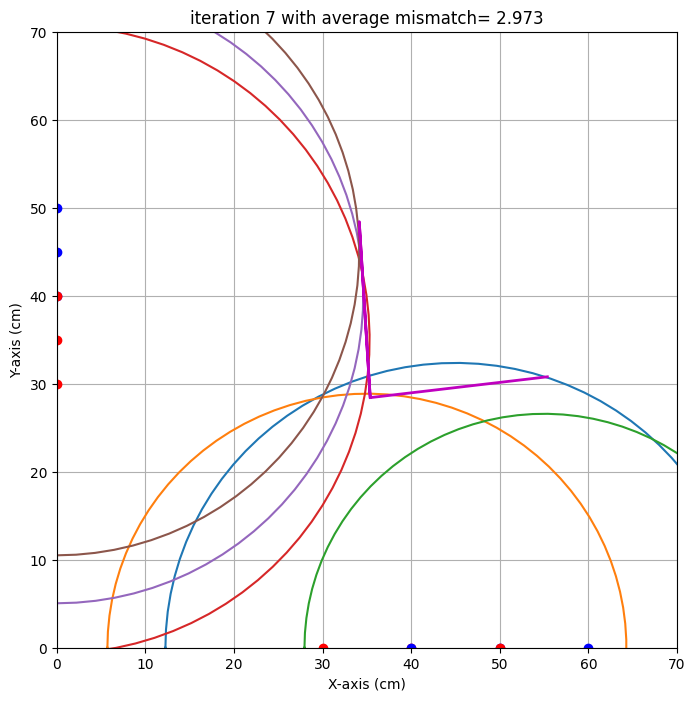

end iteration 7 with average mismatch= 2.973
end iteration 8 with average mismatch= 2.732
end iteration 9 with average mismatch= 2.630
end iteration 10 with average mismatch= 2.630
end iteration 11 with average mismatch= 2.630
end iteration 12 with average mismatch= 2.630
end iteration 13 with average mismatch= 2.630
end iteration 14 with average mismatch= 2.630
end iteration 15 with average mismatch= 2.595
end iteration 16 with average mismatch= 2.595
end iteration 17 with average mismatch= 2.595
end iteration 18 with average mismatch= 2.585
end iteration 19 with average mismatch= 2.585
end iteration 20 with average mismatch= 2.585
end iteration 21 with average mismatch= 2.585
end iteration 22 with average mismatch= 2.585
end iteration 23 with average mismatch= 2.585
end iteration 24 with average mismatch= 2.585
end iteration 25 with average mismatch= 2.585
end iteration 26 with average mismatch= 2.585
end iteration 27 with average mismatch= 2.585
end iteration 28 with average mismatc

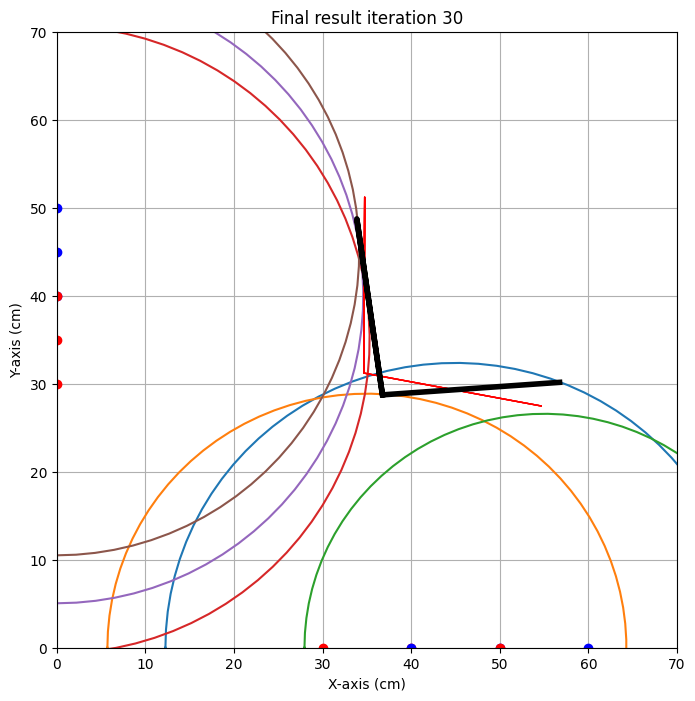

{'alpha': np.float64(4.067349017752781), 'alpha_eps': np.float64(14.645414803414571), 'beta': np.float64(-8.234132512326115), 'beta_eps': np.float64(8.450613192371206), 'x0': np.float64(36.75393546968202), 'x0_eps': np.float64(2.0813152664222656), 'y0': np.float64(28.733659863444824), 'y0_eps': np.float64(2.473775632208028)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  40   0  50   0  76.05
1  30   0  40   0  77.70
2  50   0  60   0  80.00
3   0  39   0  49  62.00
4   0  44   0  54  61.80
5   0  49   0  59  61.70


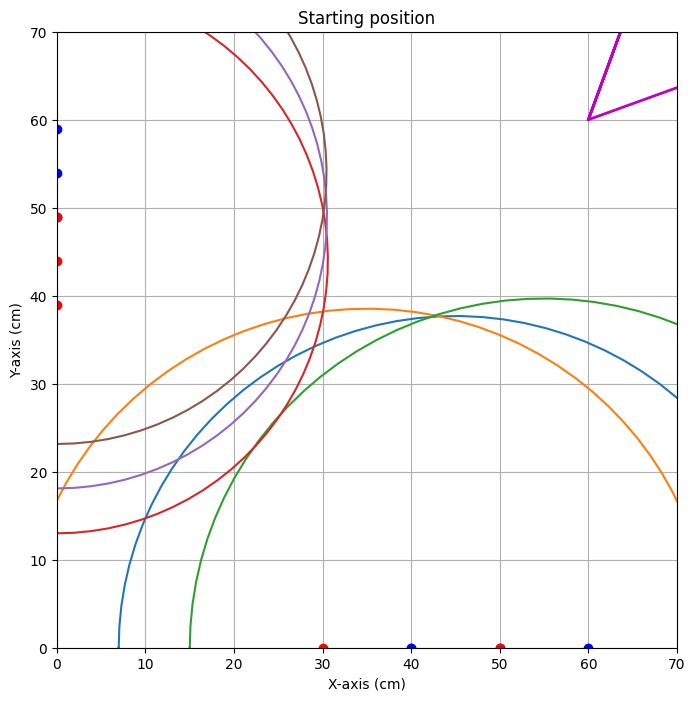


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.165


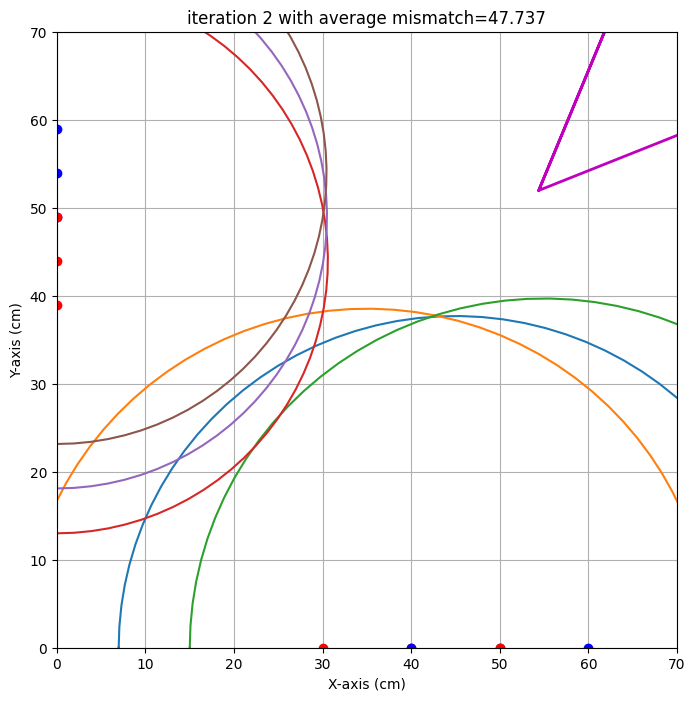

end iteration 2 with average mismatch=47.737


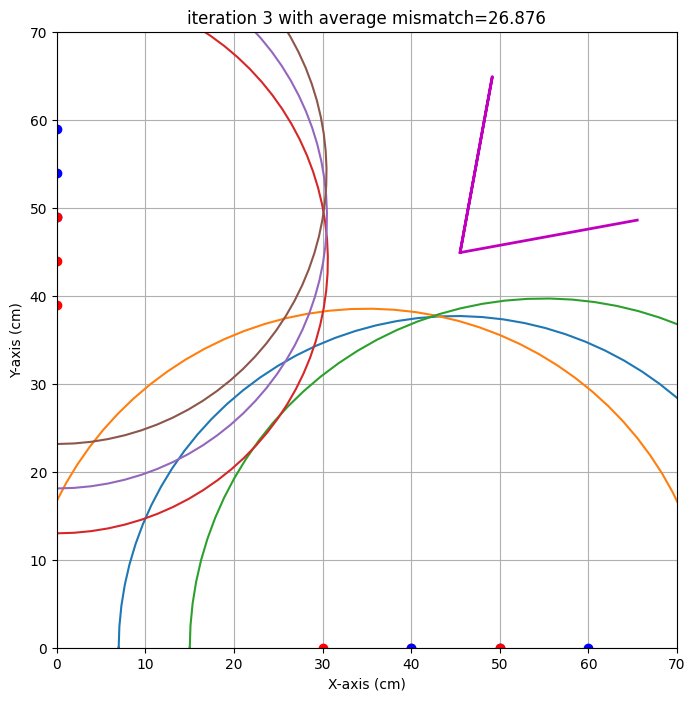

end iteration 3 with average mismatch=26.876


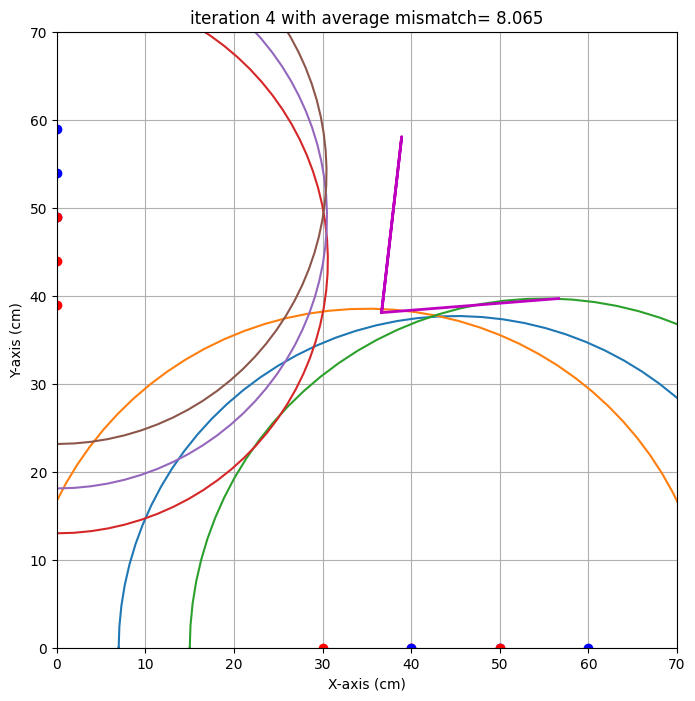

end iteration 4 with average mismatch= 8.065


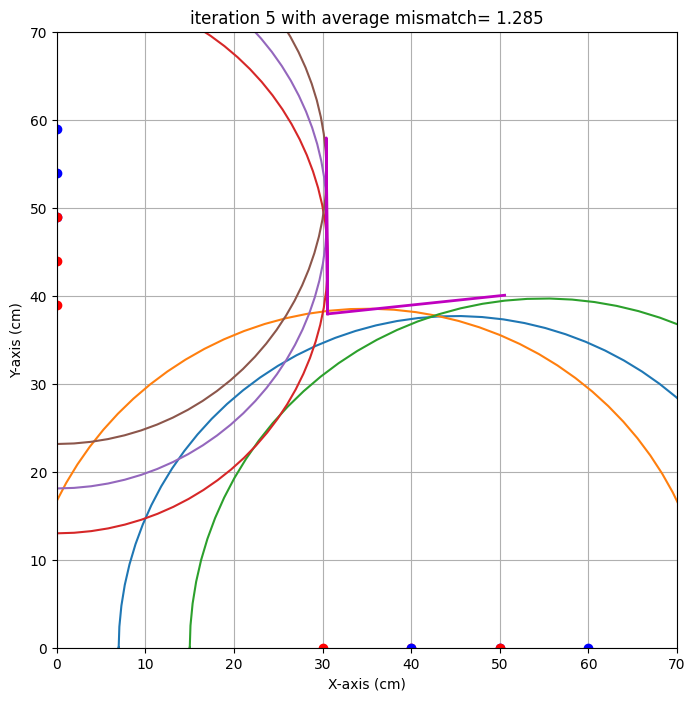

end iteration 5 with average mismatch= 1.285


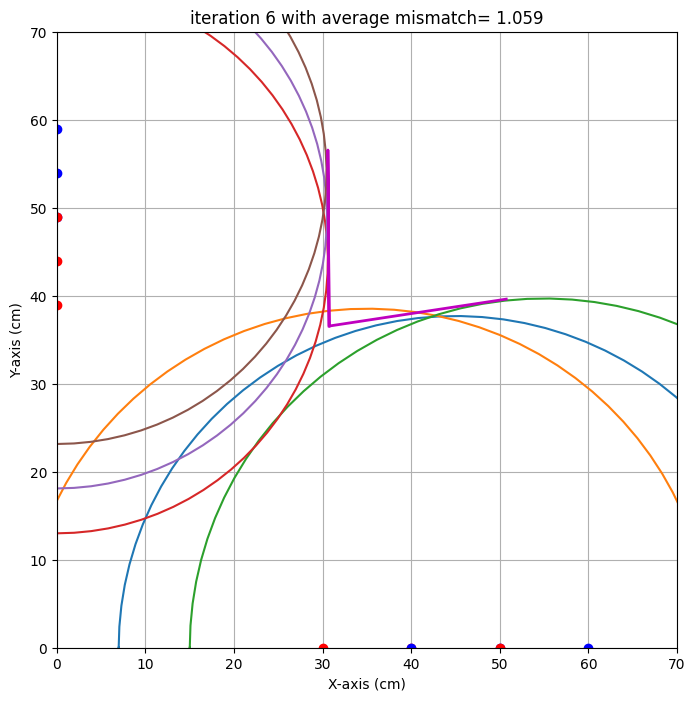

end iteration 6 with average mismatch= 1.059


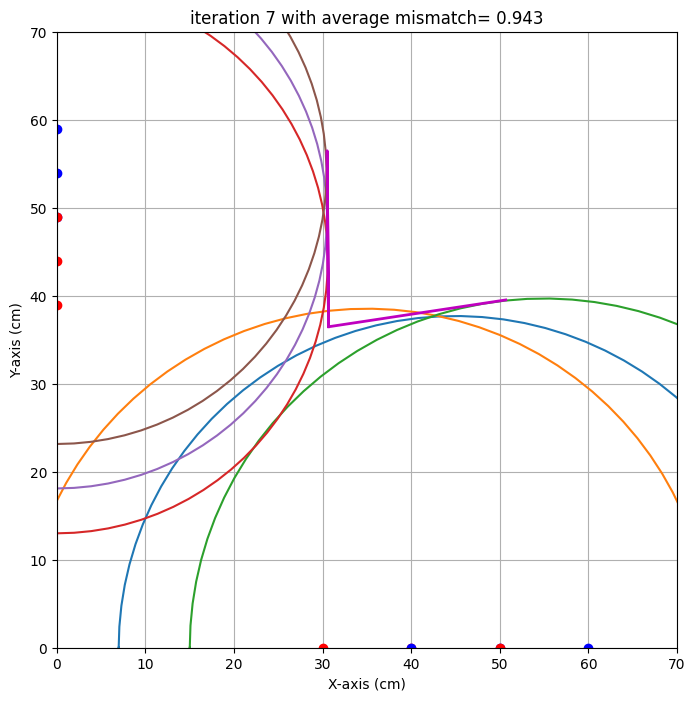

end iteration 7 with average mismatch= 0.943
end iteration 8 with average mismatch= 0.928
end iteration 9 with average mismatch= 0.922
end iteration 10 with average mismatch= 0.921
end iteration 11 with average mismatch= 0.921
end iteration 12 with average mismatch= 0.921
end iteration 13 with average mismatch= 0.921
end iteration 14 with average mismatch= 0.921
end iteration 15 with average mismatch= 0.921
end iteration 16 with average mismatch= 0.921
end iteration 17 with average mismatch= 0.921
end iteration 18 with average mismatch= 0.921
end iteration 19 with average mismatch= 0.921
end iteration 20 with average mismatch= 0.921
end iteration 21 with average mismatch= 0.921
end iteration 22 with average mismatch= 0.921
end iteration 23 with average mismatch= 0.921
end iteration 24 with average mismatch= 0.921
end iteration 25 with average mismatch= 0.921
end iteration 26 with average mismatch= 0.921
end iteration 27 with average mismatch= 0.921
end iteration 28 with average mismatc

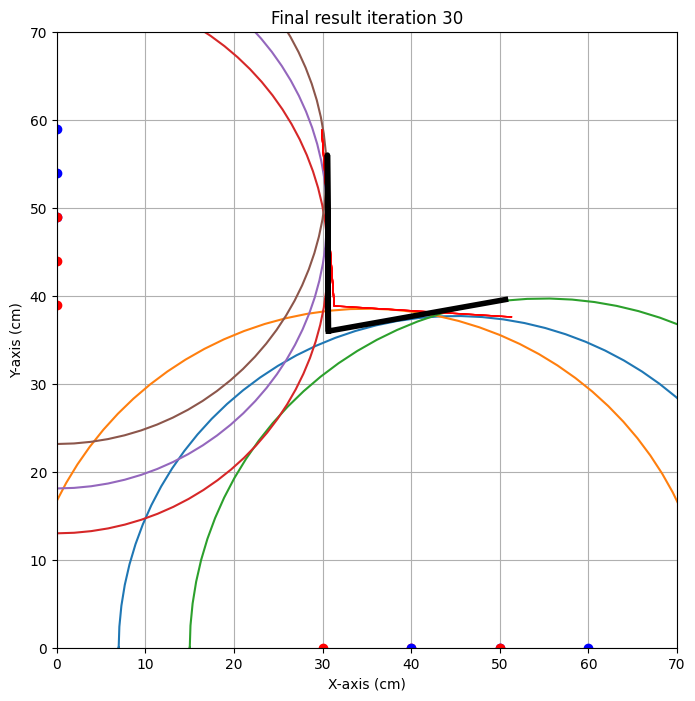

{'alpha': np.float64(10.161229216124212), 'alpha_eps': np.float64(13.741614410726132), 'beta': np.float64(-0.30014411349687453), 'beta_eps': np.float64(3.7360650344871438), 'x0': np.float64(30.649112246741225), 'x0_eps': np.float64(0.6654117942712006), 'y0': np.float64(35.97939080280593), 'y0_eps': np.float64(2.8589693643866454)}
locatie 1 
x0 target is : 36.0. Gevonden waarde: 36.8 cm met een standaardafwijking van 2.1 cm 
y0 target is : 29.0. Gevonden waarde: 28.7 cm met een standaardafwijking van 2.5 cm 
alpha target is : 9.0. Gevonden waarde: 4.1 graden met een standaardafwijking van 14.6 graad 
beta target is : -6.0. Gevonden waarde: -8.2 graden met een standaardafwijking van 8.5 graad 

locatie 2 
x0 target is : 30.3. Gevonden waarde: 30.6 cm met een standaardafwijking van 0.7 cm 
y0 target is : 39.0. Gevonden waarde: 36.0 cm met een standaardafwijking van 2.9 cm 
alpha target is : -6.5. Gevonden waarde: 10.2 graden met een standaardafwijking van 13.7 graad 
beta target is : -4.0

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':36,
                    'y0':29,
                    'alpha' : 9,
                    'beta' : -6},
           'locatie 2':{'x0':30.3,
                    'y0':39,
                    'alpha': -6.5,
                    'beta' : -4}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,65.5],
    [30,0,40,0,58.6],
    [50,0,60,0,54.1],
    [0,30,0,40,71.32],
    [0,35,0,45,69.9],
    [0,40,0,50,69]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,76.05],
    [30,0,40,0,77.7],
    [50,0,60,0,80],
    [0,39,0,49,62],
    [0,44,0,54,61.8],
    [0,49,0,59,61.7]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 9: Iteratie 2

![Alt](def4_it2.jpg "L11")

Running the imaging algorithm with the following data:
   xs    ys  xr    yr     R
0  31   0.0  41   0.0  78.0
1  36   0.0  46   0.0  76.9
2  41   0.0  51   0.0  75.7
3   0  38.5   0  48.5  62.5
4   0  43.5   0  53.5  61.5
5   0  48.5   0  58.5  61.0


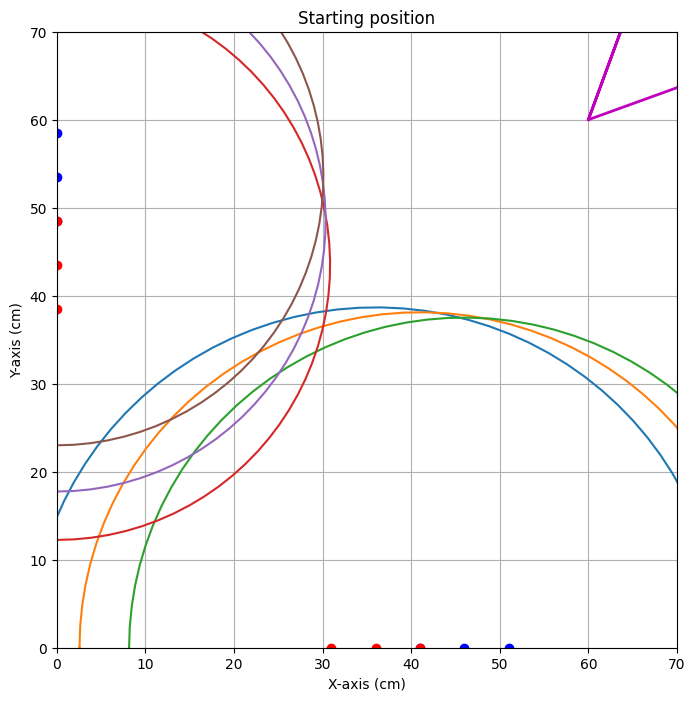


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.603


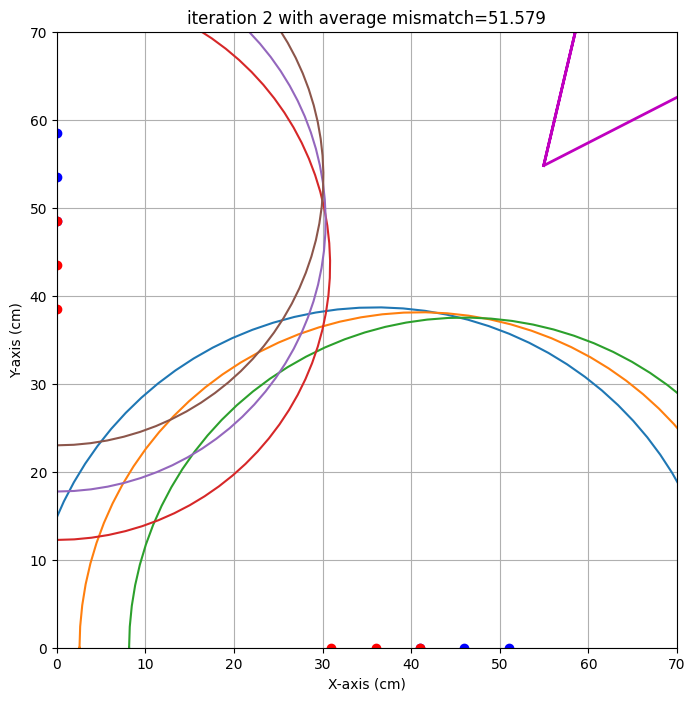

end iteration 2 with average mismatch=51.579


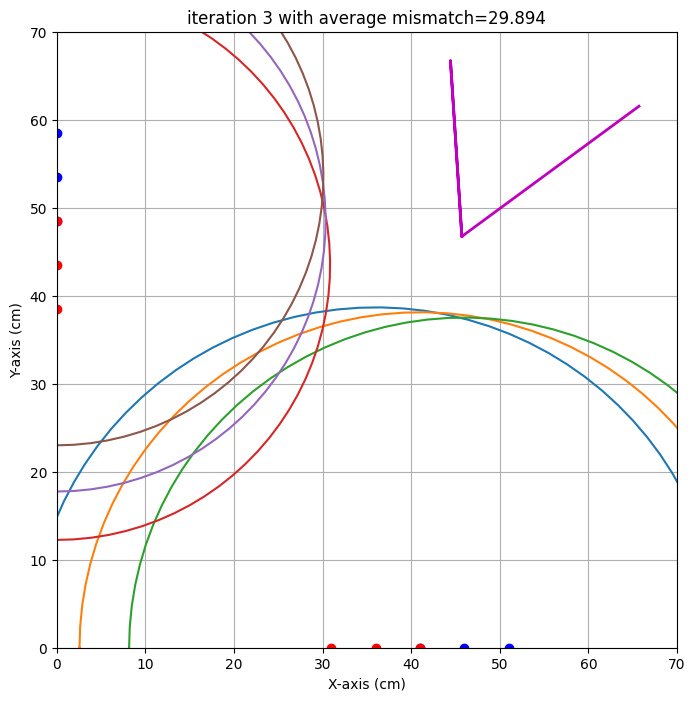

end iteration 3 with average mismatch=29.894


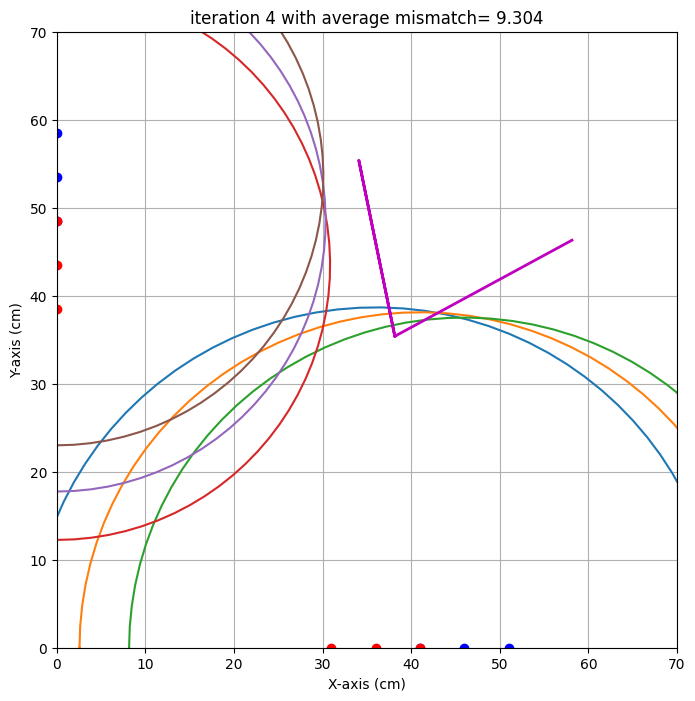

end iteration 4 with average mismatch= 9.304


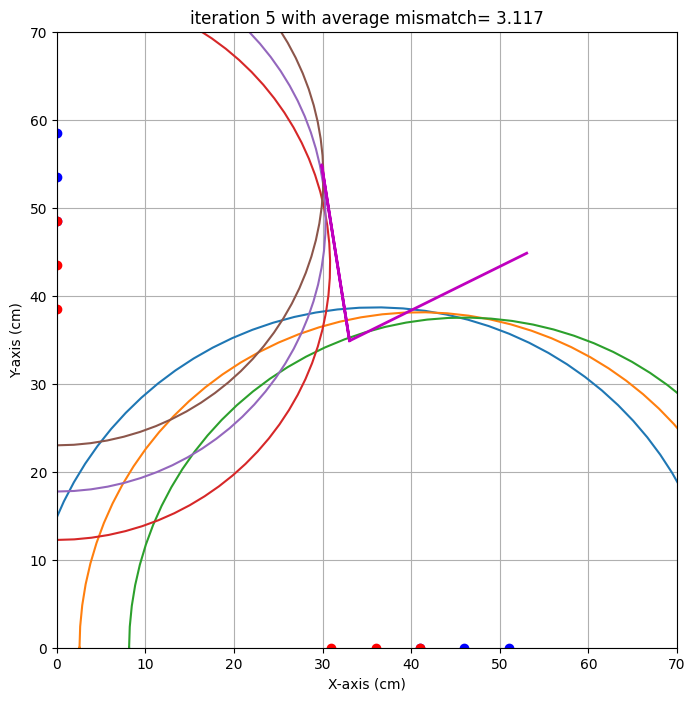

end iteration 5 with average mismatch= 3.117


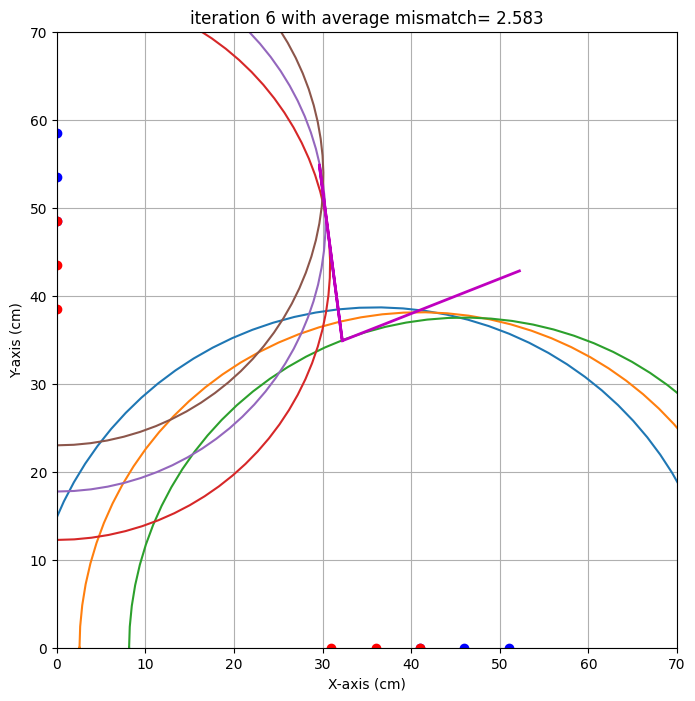

end iteration 6 with average mismatch= 2.583


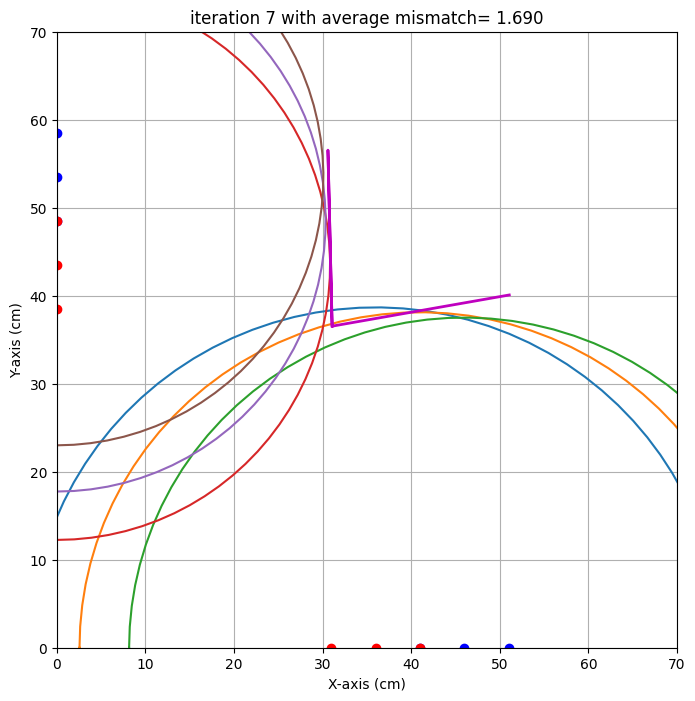

end iteration 7 with average mismatch= 1.690


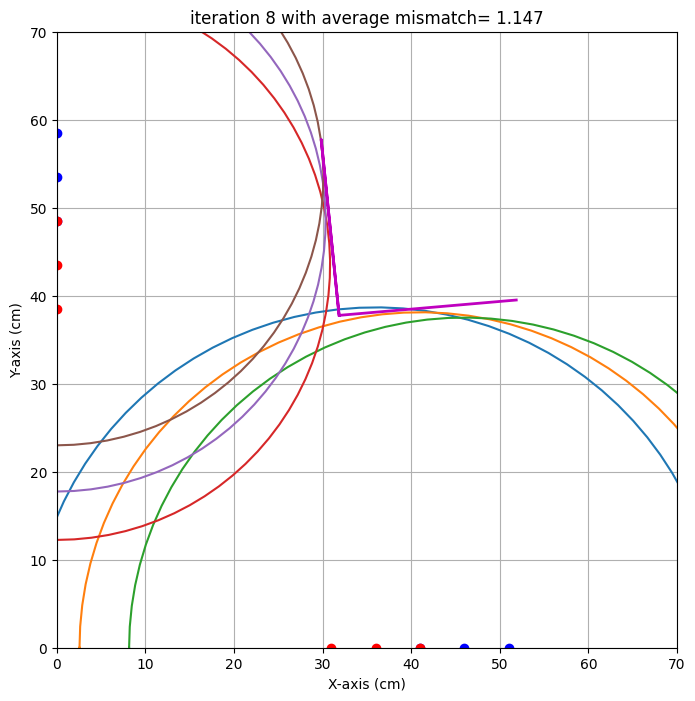

end iteration 8 with average mismatch= 1.147


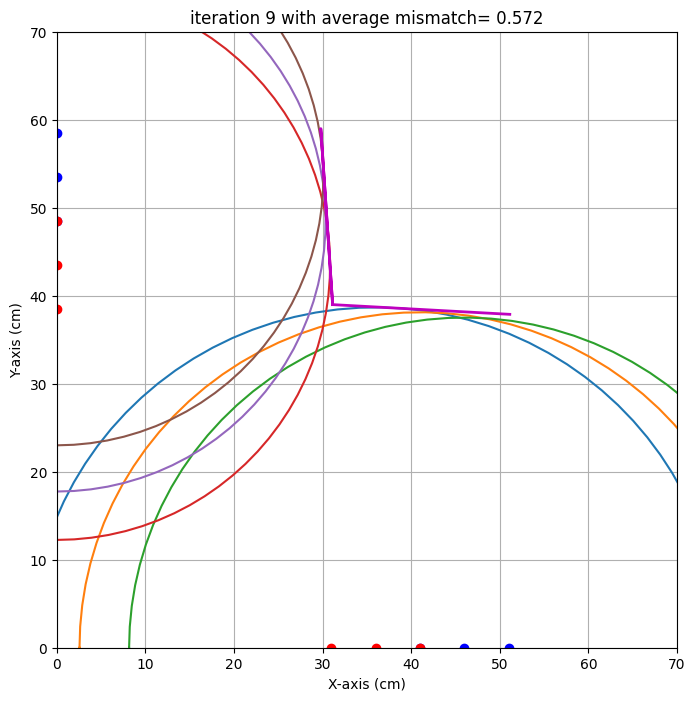

end iteration 9 with average mismatch= 0.572


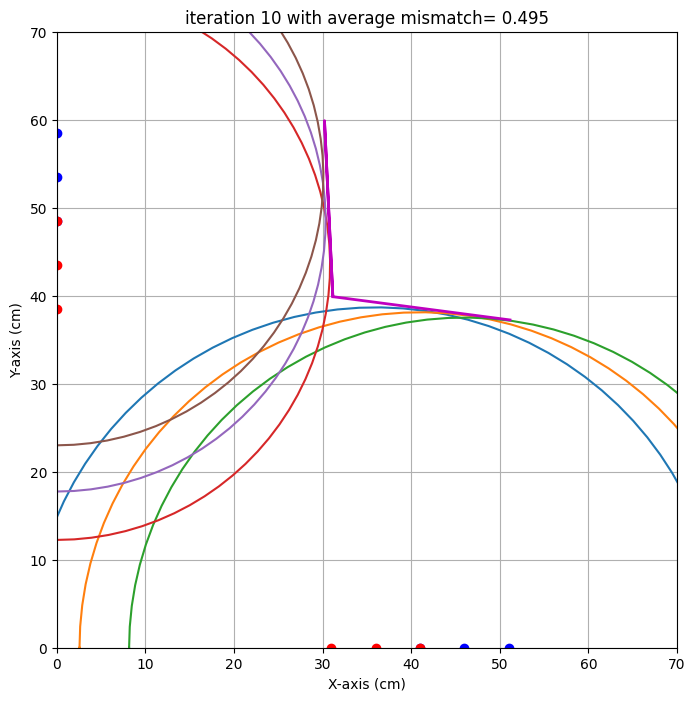

end iteration 10 with average mismatch= 0.495


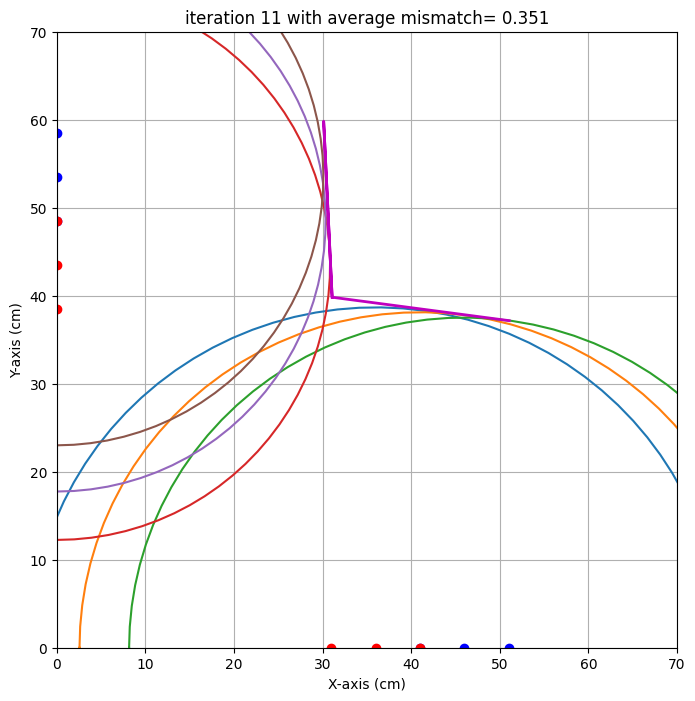

end iteration 11 with average mismatch= 0.351
end iteration 12 with average mismatch= 0.343
end iteration 13 with average mismatch= 0.339
end iteration 14 with average mismatch= 0.337
end iteration 15 with average mismatch= 0.337
end iteration 16 with average mismatch= 0.336
end iteration 17 with average mismatch= 0.336
end iteration 18 with average mismatch= 0.333
end iteration 19 with average mismatch= 0.301


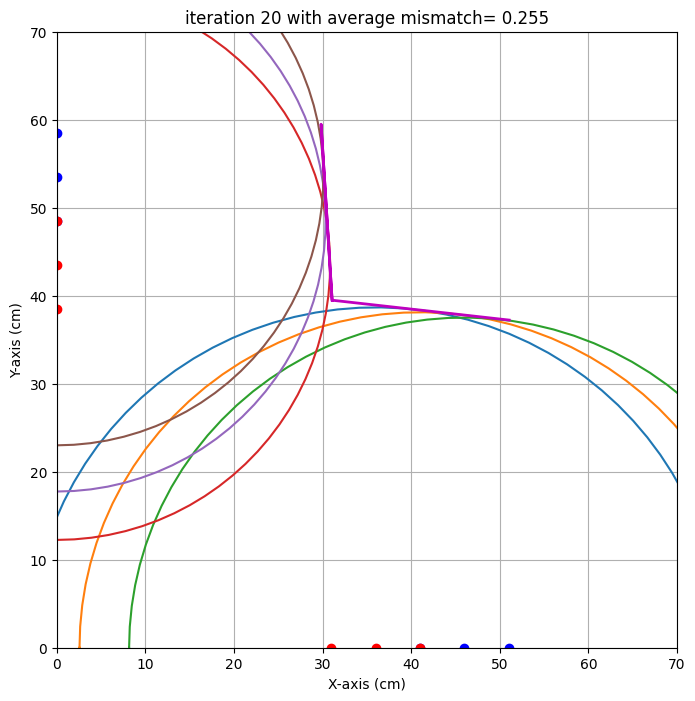

end iteration 20 with average mismatch= 0.255
end iteration 21 with average mismatch= 0.248
end iteration 22 with average mismatch= 0.248
end iteration 23 with average mismatch= 0.248
end iteration 24 with average mismatch= 0.248
end iteration 25 with average mismatch= 0.248
end iteration 26 with average mismatch= 0.248
end iteration 27 with average mismatch= 0.248
end iteration 28 with average mismatch= 0.248
end iteration 29 with average mismatch= 0.248
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.248
###############################################################################
end of iteration  30
Best alpha=  -6.97 with uncertainty=   1.57
Best beta =  -3.95 with uncertainty=   2.28
Best x0   =  31.11 with uncertainty=   0.72
Best y0   =  39.62 with uncertainty=   0.60
###############################################################################


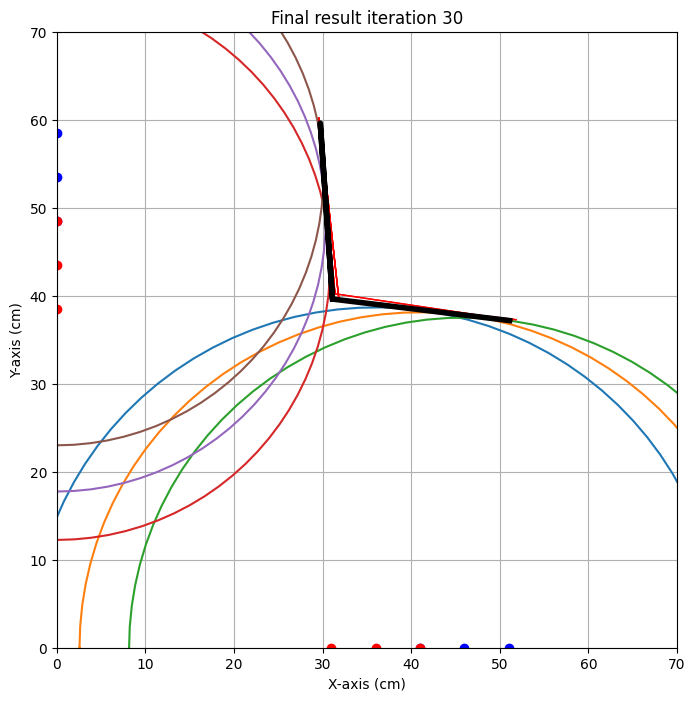

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  25,
           'y0': 41,
           'alpha' : 4,
           'beta' : -4,
          }
           

data2 = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [31,0,41,0,78],
    [36,0,46,0,76.9],
    [41,0,51,0,75.7],
    [0,38.5,0,48.5,62.5],
    [0,43.5,0,53.5,61.5],
    [0,48.5,0,58.5,61] 
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(data2)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  27   0  37   0  54.2
1  32   0  42   0  53.0
2  37   0  47   0  52.7
3   0  27   0  37  54.5
4   0  32   0  42  53.5
5   0  37   0  47  53.0


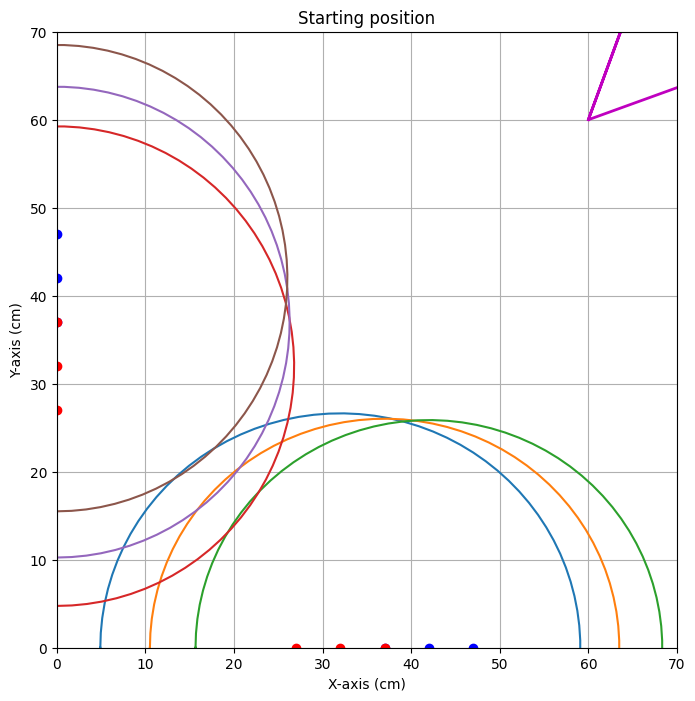


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.513


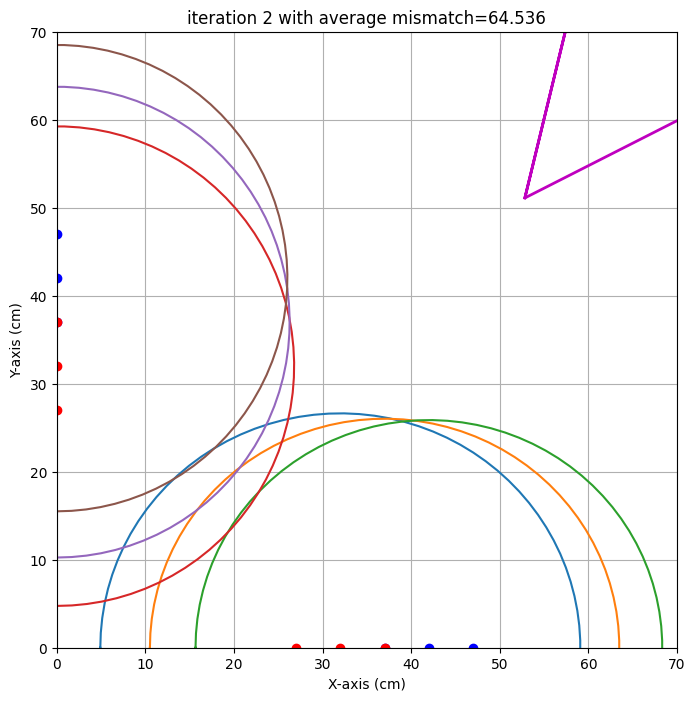

end iteration 2 with average mismatch=64.536


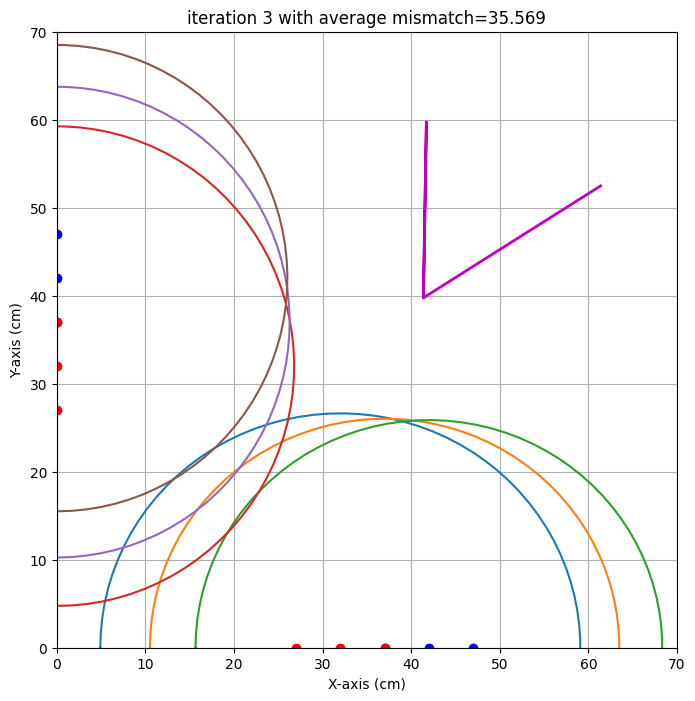

end iteration 3 with average mismatch=35.569


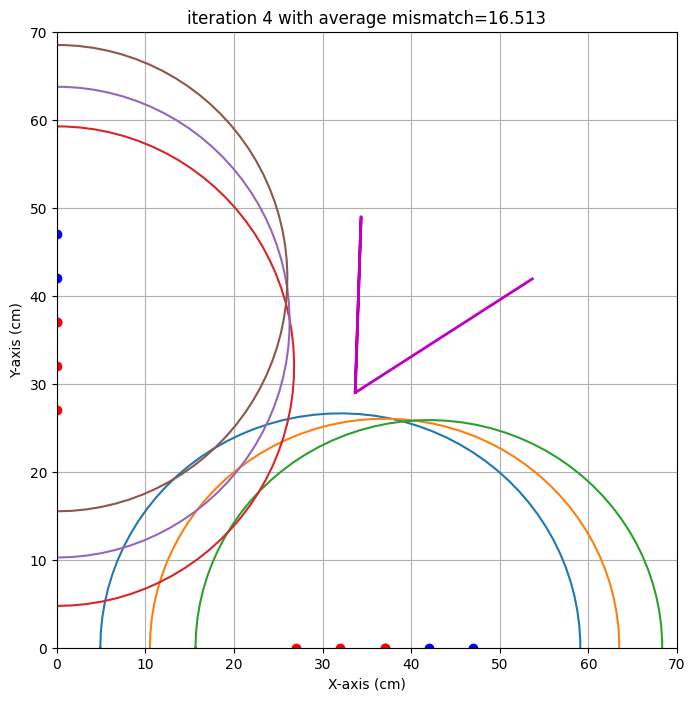

end iteration 4 with average mismatch=16.513


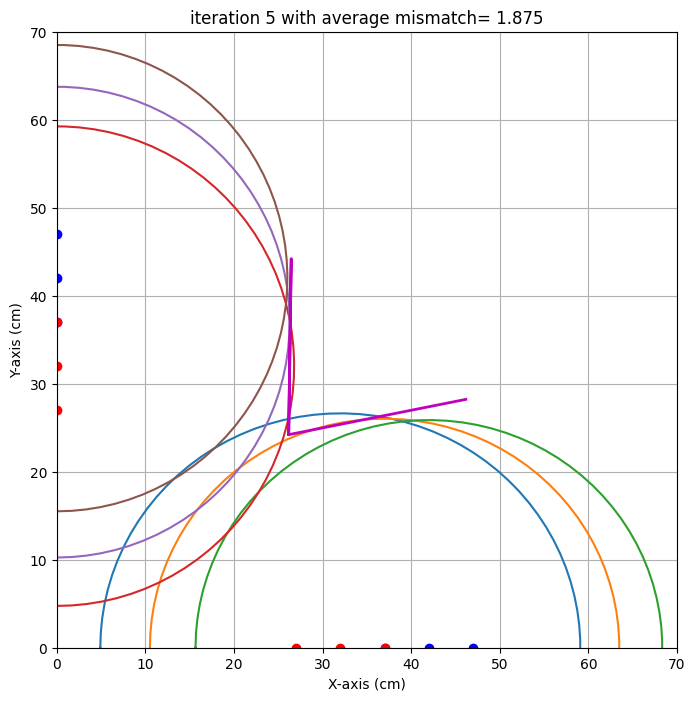

end iteration 5 with average mismatch= 1.875


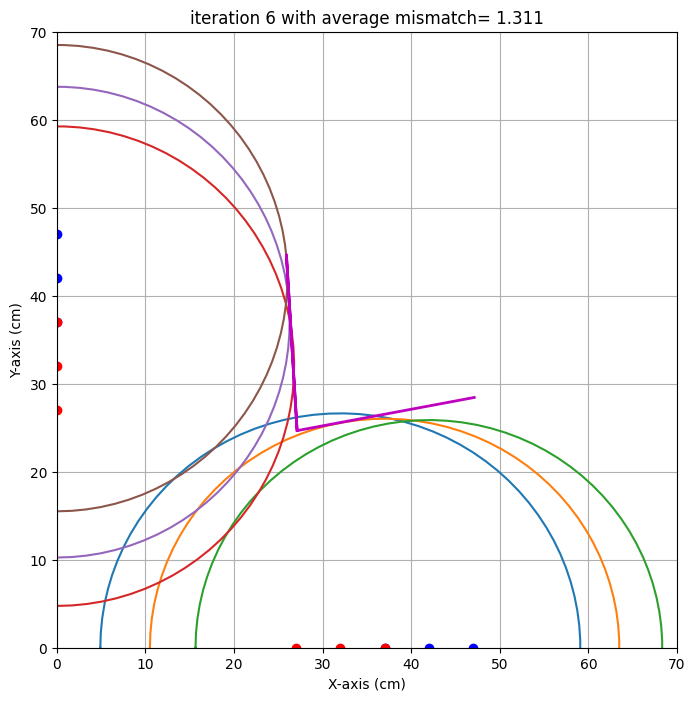

end iteration 6 with average mismatch= 1.311
end iteration 7 with average mismatch= 1.293
end iteration 8 with average mismatch= 1.292
end iteration 9 with average mismatch= 1.292
end iteration 10 with average mismatch= 1.206
end iteration 11 with average mismatch= 1.193
end iteration 12 with average mismatch= 1.188
end iteration 13 with average mismatch= 1.187
end iteration 14 with average mismatch= 1.187
end iteration 15 with average mismatch= 1.187
end iteration 16 with average mismatch= 1.187
end iteration 17 with average mismatch= 1.187
end iteration 18 with average mismatch= 1.187
end iteration 19 with average mismatch= 1.187


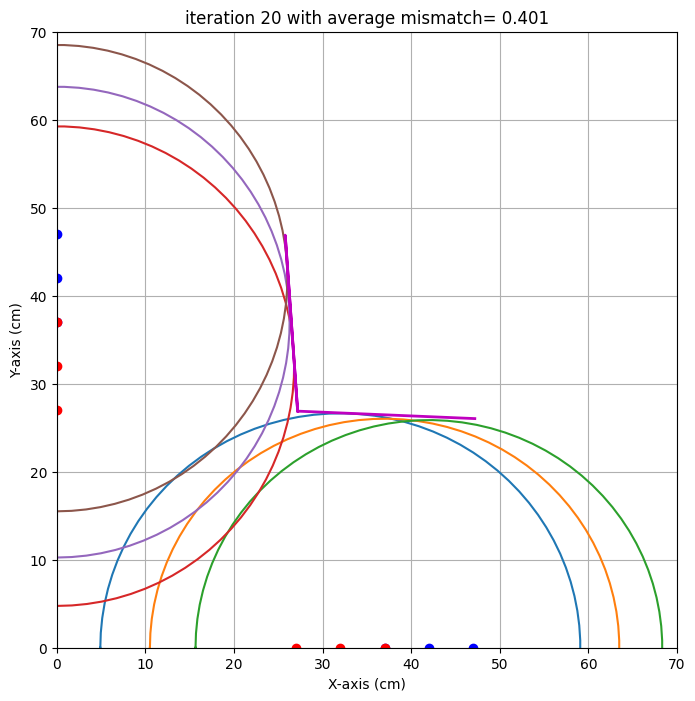

end iteration 20 with average mismatch= 0.401
end iteration 21 with average mismatch= 0.377
end iteration 22 with average mismatch= 0.375
end iteration 23 with average mismatch= 0.374
end iteration 24 with average mismatch= 0.374
end iteration 25 with average mismatch= 0.374
end iteration 26 with average mismatch= 0.374


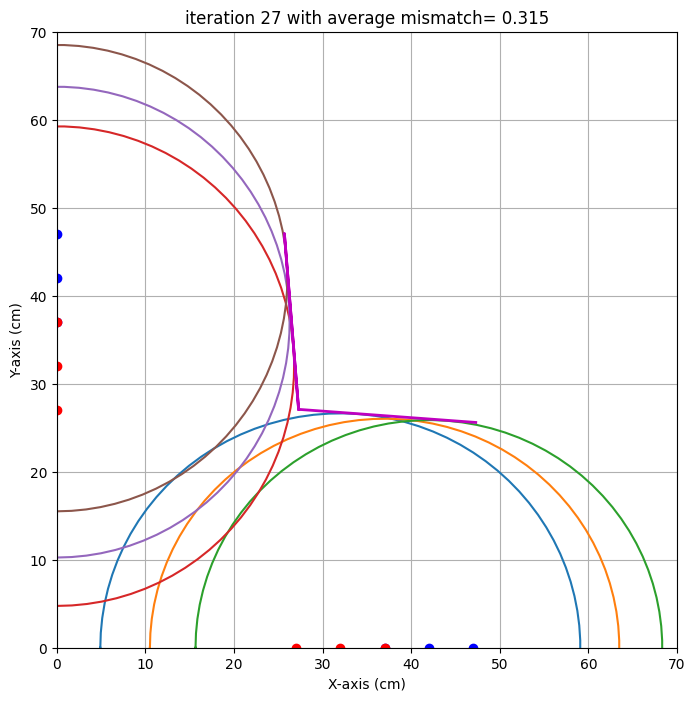

end iteration 27 with average mismatch= 0.315


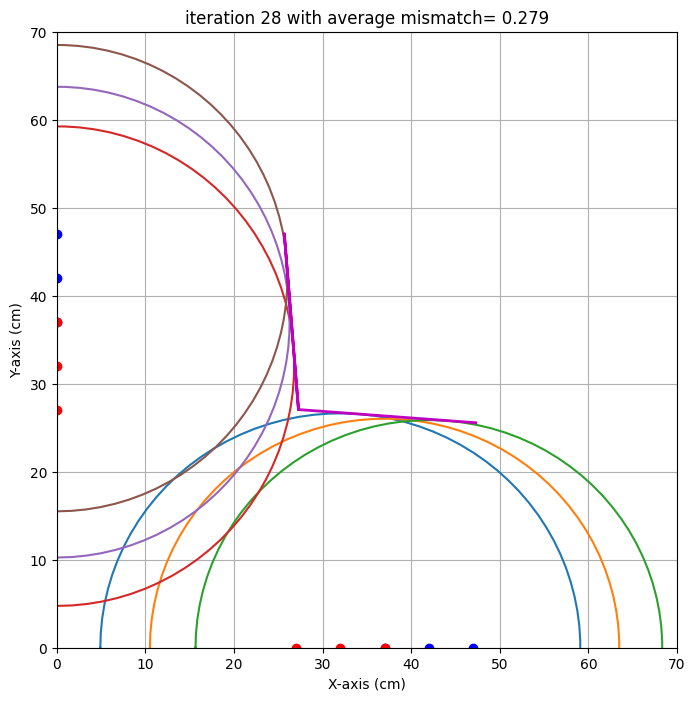

end iteration 28 with average mismatch= 0.279
end iteration 29 with average mismatch= 0.277
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.277
###############################################################################
end of iteration  30
Best alpha=  -4.28 with uncertainty=   1.40
Best beta =  -4.59 with uncertainty=   2.54
Best x0   =  27.27 with uncertainty=   0.76
Best y0   =  27.06 with uncertainty=   0.28
###############################################################################


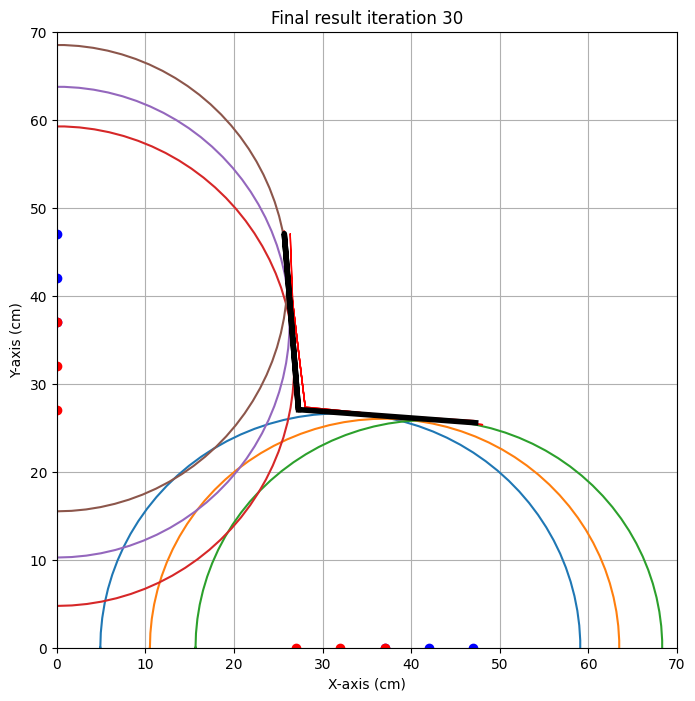

{'alpha': np.float64(-4.283399950611462), 'alpha_eps': np.float64(1.4009968428964532), 'beta': np.float64(-4.593184197127415), 'beta_eps': np.float64(2.5417409102176323), 'x0': np.float64(27.27461370696321), 'x0_eps': np.float64(0.7599078627692464), 'y0': np.float64(27.060179300390203), 'y0_eps': np.float64(0.28210011624700826)}
test locatie 
x0 target is : 26.9. Gevonden waarde: 27.3 cm met een standaardafwijking van 0.8 cm 
y0 target is : 26.7. Gevonden waarde: 27.1 cm met een standaardafwijking van 0.3 cm 
alpha target is : -2.0. Gevonden waarde: -4.3 graden met een standaardafwijking van 1.4 graad 
beta target is : -5.0. Gevonden waarde: -4.6 graden met een standaardafwijking van 2.5 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  26.9,
                    'y0':  26.7,
                    'alpha' :  -2,
                    'beta' : -5
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [27,0,37,0,54.2],
                    [32,0,42,0,53.0],
                    [37,0,47,0,52.7],
                    [0,27,0,37,54.5],
                    [0,32,0,42,53.5],
                    [0,37,0,47,53.0]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
#### algoritme Thomas Haak
Voeg een foto in van het algoritme van het eerste groepslid
![Alt](def4_alg_thomas.jpg "L11")

#### algoritme Matthias Grablowitz
Voeg een foto in van het algoritme van het tweede groepslid
![Alt](def4_alg_matthias.jpg "L11")

#### algoritme Chinming Zhu
Voeg een foto in van het algoritme van het derde groepslid
![Alt](def_alg_chinming.jpg "L11")

We besloten dat het algoritme van Thomas in principe een goede eerste versie was. We hebben dat gecombineerd met een eerste meting in het midden van de as (idee van Matthias) en zijn een nieuw algoritme gaan maken, waarbij we veel beter en sneller de andere as kunnen checken na één as te hebben gechecked.

#### algoritme iteratie 1
![Alt](def4_alg_it1.jpg "L11")

We zijn erachter gekomen dat de waarden bepaald bij de x-as minder goed zijn (de y-coordinaat en alpha), maar bij de y-as wel goed. We hebben het algoritme aangepast, door eerst een y waarde te schatten op basis van een meting aan de x-as. Dan meten we zo gericht eerst langs de y-as en dan kunnen we met die metingen weer gericht meten langs de x-as.

#### algoritme iteratie 2
![Alt](def4_it2.jpg "L11")

Deze iteratie voldeed!